# 01 - Exploratory Data Analysis

**Project** Football Betting Integrity Monitor

**Last updated:** 27.05.2026


## Overview

Steps of exploratory data analysis for German Bundesliga, English Premier League, Turkish and Greek top leagues for seasons 17/18 until 25/26.

## 1. Data inspection

In [18]:
# Inspect downloaded files

import pandas as pd
from pathlib import Path

RAW_DIR = Path('../data/raw')

# Load all CSVs into a dict keyed by filename stem (e.g. 'D1_1718')
raw_files = sorted(RAW_DIR.glob('*.csv'))
print(f"Found {len(raw_files)} CSV files")

Found 36 CSV files


In [19]:
# Row counts per league and season

rows_data = []

for f in raw_files:
    league, season = f.stem.split('_')
    df = pd.read_csv(f)
    rows_data.append({'league': league, 'season': season, 'matches': len(df)})

rows_df = pd.DataFrame(rows_data)
pivot = rows_df.pivot(index='season', columns='league', values='matches')
print(pivot.to_string())

league   D1   E0   G1   T1
season                    
1718    306  380  240  306
1819    306  380  240  306
1920    306  380  240  306
2021    306  380  240  420
2122    306  380  240  380
2223    306  380  240  342
2324    306  380  240  380
2425    306  380  233  342
2526    306  380  236  306


In [20]:
# Column schema audit

schema_data = []

for f in raw_files:
    league, season = f.stem.split('_')
    df = pd.read_csv(f, nrows=1)
    schema_data.append({
        'league': league,
        'season': season,
        'n_columns': len(df.columns),
        'columns': list(df.columns)
    })

schema_df = pd.DataFrame(schema_data)

# Summary: column counts per league per season
pivot_schema = schema_df.pivot(index='season', columns='league', values='n_columns')
print("Column counts per league/season:")
print(pivot_schema.to_string())

# Flag any seasons that differ from the most common count per league
print("\nAnomalies (seasons with non-standard column count):")
for league in ['D1', 'E0', 'T1', 'G1']:
    subset = schema_df[schema_df['league'] == league]
    most_common = subset['n_columns'].mode()[0]
    anomalies = subset[subset['n_columns'] != most_common]
    if anomalies.empty:
        print(f"  {league}: all seasons consistent ({most_common} columns)")
    else:
        for _, row in anomalies.iterrows():
            print(f"  {league} {row['season']}: {row['n_columns']} columns (expected {most_common})")

Column counts per league/season:
league   D1   E0   G1   T1
season                    
1718     64   65   64   64
1819     61   62   61   61
1920    105  106  105  105
2021    105  106  105  105
2122    105  106  105  105
2223    105  106  105  105
2324    105  106  105  105
2425    119  120  119  119
2526    131  132  131  131

Anomalies (seasons with non-standard column count):
  D1 1718: 64 columns (expected 105)
  D1 1819: 61 columns (expected 105)
  D1 2425: 119 columns (expected 105)
  D1 2526: 131 columns (expected 105)
  E0 1718: 65 columns (expected 106)
  E0 1819: 62 columns (expected 106)
  E0 2425: 120 columns (expected 106)
  E0 2526: 132 columns (expected 106)
  T1 1718: 64 columns (expected 105)
  T1 1819: 61 columns (expected 105)
  T1 2425: 119 columns (expected 105)
  T1 2526: 131 columns (expected 105)
  G1 1718: 64 columns (expected 105)
  G1 1819: 61 columns (expected 105)
  G1 2425: 119 columns (expected 105)
  G1 2526: 131 columns (expected 105)


In [21]:
# Evaluating column consistency accross all files

CORE_COLS = [
    'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
    'B365H', 'B365D', 'B365A',
    'MaxH', 'MaxD', 'MaxA',
    'AvgH', 'AvgD', 'AvgA'
]

print("Core column availability across all files:\n")
missing_any = False

for f in sorted(raw_files):
    league, season = f.stem.split('_')
    df = pd.read_csv(f, nrows=1)
    missing = [c for c in CORE_COLS if c not in df.columns]
    if missing:
        print(f"  MISSING in {league}_{season}: {missing}")
        missing_any = True

if not missing_any:
    print("  All 15 core columns present in all 36 files ✓")

Core column availability across all files:

  MISSING in D1_1718: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in D1_1819: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in E0_1718: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in E0_1819: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in G1_1718: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in G1_1819: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in T1_1718: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']
  MISSING in T1_1819: ['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA']


In [22]:
# Evaluating column consistency accross all files including closing odds

import pandas as pd
from pathlib import Path

SEASONS_TO_USE = ["1920", "2021", "2122", "2223", "2324", "2425", "2526"]

# Columns we want to verify
OPENING_COLS = ['B365H', 'B365D', 'B365A']
CLOSING_COLS = ['B365CH', 'B365CD', 'B365CA',
                'MaxCH', 'MaxCD', 'MaxCA',
                'AvgCH', 'AvgCD', 'AvgCA']
PINNACLE_COLS = ['PSH', 'PSD', 'PSA',       # opening
                 'PSCH', 'PSCD', 'PSCA']    # closing

ALL_CHECK_COLS = OPENING_COLS + CLOSING_COLS + PINNACLE_COLS

results = []

for f in sorted(Path('../data/raw').glob('*.csv')):
    league, season = f.stem.split('_')
    if season not in SEASONS_TO_USE:
        continue
    
    df = pd.read_csv(f, nrows=5)
    row = {'league': league, 'season': season}
    
    for col in ALL_CHECK_COLS:
        row[col] = '✅' if col in df.columns else '❌'
    
    results.append(row)

audit_df = pd.DataFrame(results)

# Print by league
for league in ['D1', 'E0', 'T1', 'G1']:
    print(f"\n{'='*60}")
    print(f"  {league}")
    print(f"{'='*60}")
    sub = audit_df[audit_df['league'] == league].set_index('season')
    sub = sub.drop(columns='league')
    print(sub.to_string())


  D1
       B365H B365D B365A B365CH B365CD B365CA MaxCH MaxCD MaxCA AvgCH AvgCD AvgCA PSH PSD PSA PSCH PSCD PSCA
season                                                                                                      
1920       ✅     ✅     ✅      ✅      ✅      ✅     ✅     ✅     ✅     ✅     ✅     ✅   ✅   ✅   ✅    ✅    ✅    ✅
2021       ✅     ✅     ✅      ✅      ✅      ✅     ✅     ✅     ✅     ✅     ✅     ✅   ✅   ✅   ✅    ✅    ✅    ✅
2122       ✅     ✅     ✅      ✅      ✅      ✅     ✅     ✅     ✅     ✅     ✅     ✅   ✅   ✅   ✅    ✅    ✅    ✅
2223       ✅     ✅     ✅      ✅      ✅      ✅     ✅     ✅     ✅     ✅     ✅     ✅   ✅   ✅   ✅    ✅    ✅    ✅
2324       ✅     ✅     ✅      ✅      ✅      ✅     ✅     ✅     ✅     ✅     ✅     ✅   ✅   ✅   ✅    ✅    ✅    ✅
2425       ✅     ✅     ✅      ✅      ✅      ✅     ✅     ✅     ✅     ✅     ✅     ✅   ✅   ✅   ✅    ✅    ✅    ✅
2526       ✅     ✅     ✅      ✅      ✅      ✅     ✅     ✅     ✅     ✅     ✅     ✅   ✅   ✅   ✅    ✅    ✅    ✅

  E0
       

### Note:
**As seasons 17/18 and 18/19 missing crucial data (max and average odds) we are not going to use them and only work with data for 7 seasons between 2019/2020 and 2025/2026**

## 2. Data cleaning and merging

In [23]:
# Clean the data, keep only relevant columns and combine all data into one master dataframe

CORE_COLS = [
    # Match info
    'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',

    # B365 opening odds
    'B365H', 'B365D', 'B365A',

    # B365 closing odds
    'B365CH', 'B365CD', 'B365CA',

    # Market max opening odds
    'MaxH', 'MaxD', 'MaxA',

    # Market max closing odds
    'MaxCH', 'MaxCD', 'MaxCA',

    # Market avg opening odds
    'AvgH', 'AvgD', 'AvgA',

    # Market avg closing odds
    'AvgCH', 'AvgCD', 'AvgCA',

    # Pinnacle opening odds
    'PSH', 'PSD', 'PSA',

    # Pinnacle closing odds
    'PSCH', 'PSCD', 'PSCA',
]

TIER_MAP = {
    'D1': 'elite',
    'E0': 'elite',
    'T1': 'mid_tier',
    'G1': 'mid_tier'
}

SEASONS_TO_USE = ["1920", "2021", "2122", "2223", "2324", "2425", "2526"]

frames = []

for f in sorted(Path('../data/raw').glob('*.csv')):
    league, season = f.stem.split('_')

    if season not in SEASONS_TO_USE:
        continue

    df = pd.read_csv(f, usecols=CORE_COLS)
    df['league'] = league
    df['season'] = season
    df['tier']   = TIER_MAP[league]

    frames.append(df)

master = pd.concat(frames, ignore_index=True)

print(f"Total rows:    {len(master):,}")
print(f"Total columns: {len(master.columns)}")
print(f"\nColumns loaded:")
print([c for c in master.columns])

Total rows:    8,947
Total columns: 33

Columns loaded:
['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'B365H', 'B365D', 'B365A', 'PSH', 'PSD', 'PSA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365CH', 'B365CD', 'B365CA', 'PSCH', 'PSCD', 'PSCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'league', 'season', 'tier']


In [24]:
# Fix data types

master['Date'] = pd.to_datetime(master['Date'], dayfirst=True)
master['FTHG'] = master['FTHG'].astype('Int64')
master['FTAG'] = master['FTAG'].astype('Int64')

odds_cols = [c for c in master.columns if c not in 
             ['Date', 'HomeTeam', 'AwayTeam', 'FTR', 'league', 'season', 'tier', 'FTHG', 'FTAG']]
for col in odds_cols:
    master[col] = pd.to_numeric(master[col], errors='coerce')

print(master.dtypes)
print(f"\nDate range: {master['Date'].min().date()} → {master['Date'].max().date()}")

Date        datetime64[us]
HomeTeam               str
AwayTeam               str
FTHG                 Int64
FTAG                 Int64
FTR                    str
B365H              float64
B365D              float64
B365A              float64
PSH                float64
PSD                float64
PSA                float64
MaxH               float64
MaxD               float64
MaxA               float64
AvgH               float64
AvgD               float64
AvgA               float64
B365CH             float64
B365CD             float64
B365CA             float64
PSCH               float64
PSCD               float64
PSCA               float64
MaxCH              float64
MaxCD              float64
MaxCA              float64
AvgCH              float64
AvgCD              float64
AvgCA              float64
league                 str
season                 str
tier                   str
dtype: object

Date range: 2019-08-09 → 2026-05-24


In [25]:
# Double-check all column names

master.head(2)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,B365H,B365D,B365A,PSH,...,PSCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,league,season,tier
0,2019-08-16,Bayern Munich,Hertha,2,2,D,1.14,8.0,15.0,1.19,...,17.38,1.25,9.1,19.25,1.17,8.0,15.67,D1,1920,elite
1,2019-08-17,Dortmund,Augsburg,5,1,H,1.20,7.0,13.0,1.23,...,20.11,1.20,8.8,26.00,1.16,8.1,18.29,D1,1920,elite


### Column decode

**Match Identity**
- **Date** - Date the match was played
- **HomeTeam** - Name of the home team
- **AwayTeam** - Name of the away team

**Match Result**
- **FTHG** - Full Time Home Goals - Goals scored by home team
- **FTAG** - Full Time Away Goals - Goals scored by away team
- **FTR** - Full Time Result - H = Home win, D = Draw, A = Away win

**Bet365 Opening Odds**
- **B365H** - Bet365 Home Win Odds - Opening price before betting activity
- **B365D** - Bet365 Draw Odds - Opening price before betting activity
- **B365A** - Bet365 Away Win Odds - Opening price before betting activity

**Bet365 Closing Odds**
- **B365CH** - Bet365 Home Win Closing Odds - Final price just before kickoff
- **B365CD** - Bet365 Draw Closing Odds - Final price just before kickoff
- **B365CA** - Bet365 Away Win Closing Odds - Final price just before kickoff

**Pinnacle Opening Odds**
- **PSH** - Pinnacle Home Win Opening Odds - Sharpest bookmaker, opening price
- **PSD** - Pinnacle Draw Opening Odds - Sharpest bookmaker, opening price
- **PSA** - Pinnacle Away Win Opening Odds - Sharpest bookmaker, opening price

**Pinnacle Closing Odds**
- **PSCH** - Pinnacle Home Win Closing Odds - Sharpest bookmaker, final price
- **PSCD** - Pinnacle Draw Closing Odds - Sharpest bookmaker, final price
- **PSCA** - Pinnacle Away Win Closing Odds - Sharpest bookmaker, final price

**Market Maximum Opening Odds**
- **MaxH** - Maximum Home Win Opening Odds - Best available price across all bookmakers at open
- **MaxD** - Maximum Draw Opening Odds - Best available price across all bookmakers at open
- **MaxA** - Maximum Away Win Opening Odds - Best available price across all bookmakers at open

**Market Maximum Closing Odds**
- **MaxCH** - Maximum Home Win Closing Odds - Best available price across all bookmakers at close
- **MaxCD** - Maximum Draw Closing Odds - Best available price across all bookmakers at close
- **MaxCA** - Maximum Away Win Closing Odds - Best available price across all bookmakers at close

**Market Average Opening Odds**
- **AvgH** - Average Home Win Opening Odds - Market consensus across all bookmakers at open
- **AvgD** - Average Draw Opening Odds - Market consensus across all bookmakers at open
- **AvgA** - Average Away Win Opening Odds - Market consensus across all bookmakers at open

**Market Average Closing Odds**
- **AvgCH** - Average Home Win Closing Odds - Market consensus across all bookmakers at close
- **AvgCD** - Average Draw Closing Odds - Market consensus across all bookmakers at close
- **AvgCA** - Average Away Win Closing Odds - Market consensus across all bookmakers at close

**Drift Features** (closing − opening = how much the market moved)
- **b365_drift_H** - Bet365 Home Win Drift - Positive = odds drifted up (home team became less likely)
- **b365_drift_D** - Bet365 Draw Drift - Positive = draw became less likely
- **b365_drift_A** - Bet365 Away Win Drift - Positive = away team became less likely
- **pinnacle_drift_H** - Pinnacle Home Win Drift - Sharp money movement on home outcome
- **pinnacle_drift_D** - Pinnacle Draw Drift - Sharp money movement on draw outcome
- **pinnacle_drift_A** - Pinnacle Away Win Drift - Sharp money movement on away outcome

**Spread Features** (Max − Avg = bookmaker disagreement)
- **opening_spread_H** - Opening Bookmaker Spread Home - Disagreement at market open
- **opening_spread_D** - Opening Bookmaker Spread Draw - Disagreement at market open
- **opening_spread_A** - Opening Bookmaker Spread Away - Disagreement at market open
- **closing_spread_H** - Closing Bookmaker Spread Home - Disagreement at market close
- **closing_spread_D** - Closing Bookmaker Spread Draw - Disagreement at market close
- **closing_spread_A** - Closing Bookmaker Spread Away - Disagreement at market close
- **max_opening_spread** - Maximum spread across H/D/A at open - Single worst-case disagreement
- **max_closing_spread** - Maximum spread across H/D/A at close - Single worst-case disagreement

**B365 vs Market Gap**
- **b365_vs_market_H** - MaxCH − B365CH - How far B365 sits below market ceiling at close
- **b365_vs_market_D** - MaxCD − B365CD - How far B365 sits below market ceiling at close
- **b365_vs_market_A** - MaxCA − B365CA - How far B365 sits below market ceiling at close

**Implied Probability Features**
- **implied_prob_sum_open** - Opening overround (1/B365H + 1/B365D + 1/B365A) - Bookmaker margin at open
- **implied_prob_sum_close** - Closing overround (1/B365CH + 1/B365CD + 1/B365CA) - Bookmaker margin at close

**Season Position Features** (added during EDA)
- **match_rank** - Match position within the league-season by date
- **season_size** - Total matches in that league-season
- **season_pct** - Relative position in season (0.0 = first match, 1.0 = last match)
- **season_quintile** - Season phase bucket (Q1 = first 20% … Q5 = last 20%)

**Metadata** (added by us)
- **league** - League Code - D1 = Bundesliga, E0 = EPL, T1 = Turkey, G1 = Greece
- **season** - Season Code - e.g. 1920 = 2019/20 season
- **tier** - League Tier - elite = (Bundesliga, EPL), mid_tier = (Turkey, Greece)

In [ ]:
## Data quality audit

# Null audit

print("=== Null counts (non-zero only) ===")
nulls = master.isnull().sum()
print(nulls[nulls > 0])
print(f"\nTotal rows: {len(master):,}")

=== Null counts (non-zero only) ===
B365H      56
B365D      56
B365A      56
PSH       756
PSD       756
PSA       756
MaxH       30
MaxD       30
MaxA       30
AvgH       30
AvgD       30
AvgA       30
B365CH     29
B365CD     29
B365CA     29
PSCH      709
PSCD      709
PSCA      709
MaxCH      29
MaxCD      29
MaxCA      29
AvgCH      29
AvgCD      29
AvgCA      29
dtype: int64

Total rows: 8,947


In [27]:
# Drop rows missing closing odds (our primary analysis columns)
before = len(master)
master = master.dropna(subset=['MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA'])
after = len(master)

print(f"Rows dropped: {before - after}")
print(f"Rows remaining: {after:,}")
print(f"\nRemaining nulls:")
nulls = master.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "None ✓")

Rows dropped: 29
Rows remaining: 8,918

Remaining nulls:
B365H     27
B365D     27
B365A     27
PSH      727
PSD      727
PSA      727
MaxH       1
MaxD       1
MaxA       1
AvgH       1
AvgD       1
AvgA       1
PSCH     680
PSCD     680
PSCA     680
dtype: int64


In [28]:
# Analyzing pinnacle odds null distribution

print("=== Pinnacle null distribution ===\n")

# Closing nulls by league and season (most important)
psc_nulls = master[master['PSCH'].isnull()].groupby(['league','season']).size()
print("Pinnacle CLOSING nulls by league/season:")
print(psc_nulls)

print(f"\nTotal Pinnacle closing nulls: {master['PSCH'].isnull().sum()}")
print(f"As % of dataset: {master['PSCH'].isnull().sum()/len(master)*100:.1f}%")

# Check if Pinnacle nulls overlap with B365 nulls
both_null = master[master['PSCH'].isnull() & master['B365CH'].isnull()]
print(f"\nRows missing BOTH Pinnacle and B365 closing: {len(both_null)}")
print(f"Rows missing Pinnacle only: {master['PSCH'].isnull().sum() - len(both_null)}")

=== Pinnacle null distribution ===

Pinnacle CLOSING nulls by league/season:
league  season
D1      2526      157
E0      2526      170
G1      2526      181
T1      2122        1
        2526      171
dtype: int64

Total Pinnacle closing nulls: 680
As % of dataset: 7.6%

Rows missing BOTH Pinnacle and B365 closing: 0
Rows missing Pinnacle only: 680


In [29]:
## Checking if nulls in b365 odds are consistent with nulls in max odds

null_b365 = set(master[master['B365H'].isnull()].index)
null_max = set(master[master['MaxH'].isnull()].index)

print(f"Rows missing B365 only:        {len(null_b365 - null_max)}")
print(f"Rows missing Max/Avg only:      {len(null_max - null_b365)}")
print(f"Rows missing both:              {len(null_b365 & null_max)}")
print(f"Total rows with any null:       {len(null_b365 | null_max)}")

Rows missing B365 only:        26
Rows missing Max/Avg only:      0
Rows missing both:              1
Total rows with any null:       27


In [30]:
## Drop unrecoverable rows that can't be used for our analysis

# Drop rows where Max/Avg are null (no odds data at all - unusable)
before = len(master)
master = master.dropna(subset=['MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA'])
after = len(master)

print(f"Rows dropped: {before - after}")
print(f"Rows remaining: {after:,}")
print(f"\nRemaining nulls:")
print(master.isnull().sum()[master.isnull().sum() > 0])

Rows dropped: 1
Rows remaining: 8,917

Remaining nulls:
B365H     26
B365D     26
B365A     26
PSH      726
PSD      726
PSA      726
PSCH     680
PSCD     680
PSCA     680
dtype: int64


## 3. Save the master dataset as CSV file

In [31]:
## Save the master dataset as CSV file

master.to_csv('../data/processed/master.csv', index=False)
print(f"Saved: data/processed/master.csv")
print(f"Shape: {master.shape}")

Saved: data/processed/master.csv
Shape: (8917, 33)


## 3.1 Compute drift and closing spread features

In [60]:
# B365 drift (closing - opening)
master['b365_drift_H'] = master['B365CH'] - master['B365H']
master['b365_drift_D'] = master['B365CD'] - master['B365D']
master['b365_drift_A'] = master['B365CA'] - master['B365A']

# Pinnacle drift (closing - opening)
master['pinnacle_drift_H'] = master['PSCH'] - master['PSH']
master['pinnacle_drift_D'] = master['PSCD'] - master['PSD']
master['pinnacle_drift_A'] = master['PSCA'] - master['PSA']

# Closing spread (Max - Avg at close)
master['closing_spread_H'] = master['MaxCH'] - master['AvgCH']
master['closing_spread_D'] = master['MaxCD'] - master['AvgCD']
master['closing_spread_A'] = master['MaxCA'] - master['AvgCA']

# Opening spread (Max - Avg at open) — already had these, recompute cleanly
master['opening_spread_H'] = master['MaxH'] - master['AvgH']
master['opening_spread_D'] = master['MaxD'] - master['AvgD']
master['opening_spread_A'] = master['MaxA'] - master['AvgA']

# Max closing spread across all outcomes
master['max_closing_spread'] = master[['closing_spread_H','closing_spread_D','closing_spread_A']].max(axis=1)
master['max_opening_spread'] = master[['opening_spread_H','opening_spread_D','opening_spread_A']].max(axis=1)

# B365 vs market closing gap (how far B365 sits below market ceiling at close)
master['b365_vs_market_H'] = master['MaxCH'] - master['B365CH']
master['b365_vs_market_D'] = master['MaxCD'] - master['B365CD']
master['b365_vs_market_A'] = master['MaxCA'] - master['B365CA']

# Implied probability sum — closing odds
master['implied_prob_sum_close'] = (
    1/master['B365CH'] + 1/master['B365CD'] + 1/master['B365CA']
)

# Implied probability sum — opening odds (keep for comparison)
master['implied_prob_sum_open'] = (
    1/master['B365H'] + 1/master['B365D'] + 1/master['B365A']
)

# Spread change (closing − opening spread)
master['spread_change_H'] = master['closing_spread_H'] - master['opening_spread_H']
master['spread_change_D'] = master['closing_spread_D'] - master['opening_spread_D']
master['spread_change_A'] = master['closing_spread_A'] - master['opening_spread_A']
master['max_spread_change'] = master[['spread_change_H','spread_change_D','spread_change_A']].max(axis=1)

print(f"New feature columns added: {33 - 33 + len([c for c in master.columns if c not in ['Date','HomeTeam','AwayTeam','FTHG','FTAG','FTR','B365H','B365D','B365A','PSH','PSD','PSA','MaxH','MaxD','MaxA','AvgH','AvgD','AvgA','B365CH','B365CD','B365CA','PSCH','PSCD','PSCA','MaxCH','MaxCD','MaxCA','AvgCH','AvgCD','AvgCA','league','season','tier']])}")
print(f"Total columns: {len(master.columns)}")
print(f"\nNew columns:")
new_cols = ['b365_drift_H','b365_drift_D','b365_drift_A',
            'pinnacle_drift_H','pinnacle_drift_D','pinnacle_drift_A',
            'closing_spread_H','closing_spread_D','closing_spread_A',
            'opening_spread_H','opening_spread_D','opening_spread_A',
            'max_closing_spread','max_opening_spread',
            'b365_vs_market_H','b365_vs_market_D','b365_vs_market_A',
            'implied_prob_sum_close','implied_prob_sum_open']
print(new_cols)

print(f"\nSample stats on key drift features:")
for col in ['b365_drift_H', 'pinnacle_drift_H', 'closing_spread_H']:
    print(f"  {col}: mean={master[col].mean():.4f}, std={master[col].std():.4f}, "
          f"min={master[col].min():.4f}, max={master[col].max():.4f}")

New feature columns added: 33
Total columns: 66

New columns:
['b365_drift_H', 'b365_drift_D', 'b365_drift_A', 'pinnacle_drift_H', 'pinnacle_drift_D', 'pinnacle_drift_A', 'closing_spread_H', 'closing_spread_D', 'closing_spread_A', 'opening_spread_H', 'opening_spread_D', 'opening_spread_A', 'max_closing_spread', 'max_opening_spread', 'b365_vs_market_H', 'b365_vs_market_D', 'b365_vs_market_A', 'implied_prob_sum_close', 'implied_prob_sum_open']

Sample stats on key drift features:
  b365_drift_H: mean=0.0008, std=0.5150, min=-7.0000, max=8.0000
  pinnacle_drift_H: mean=0.0414, std=0.5170, min=-6.8100, max=7.2900
  closing_spread_H: mean=0.2375, std=0.8111, min=0.0100, max=64.1100


In [33]:
## Identifying outliers

print("=== Extreme value audit ===\n")

checks = {
    'b365_drift_H':     (-5, 5),
    'b365_drift_D':     (-5, 5),
    'b365_drift_A':     (-5, 5),
    'pinnacle_drift_H': (-5, 5),
    'pinnacle_drift_D': (-5, 5),
    'pinnacle_drift_A': (-5, 5),
    'closing_spread_H': (0, 5),
    'closing_spread_D': (0, 5),
    'closing_spread_A': (0, 5),
}

for col, (lo, hi) in checks.items():
    outliers = master[(master[col] < lo) | (master[col] > hi)]
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers outside [{lo}, {hi}]")
        print(master.loc[outliers.index, 
              ['Date','HomeTeam','AwayTeam','league','season',col]].to_string(index=False))
        print()

=== Extreme value audit ===

b365_drift_H: 8 outliers outside [-5, 5]
      Date  HomeTeam   AwayTeam league season  b365_drift_H
2019-09-14   Norwich   Man City     E0   1920           8.0
2021-12-19 Newcastle   Man City     E0   2122           8.0
2020-02-09 Atromitos Olympiakos     G1   1920           5.5
2021-01-31   Apollon Olympiakos     G1   2021          -7.0
2022-08-20     Lamia        AEK     G1   2223           6.5
2023-03-19 Volos NFC Olympiakos     G1   2223         -25.0
2023-12-03 Volos NFC Olympiakos     G1   2324          -6.5
2024-03-10     Lamia        AEK     G1   2324           5.5

b365_drift_D: 1 outliers outside [-5, 5]
      Date HomeTeam AwayTeam league season  b365_drift_D
2020-07-26 Man City  Norwich     E0   1920           8.0

b365_drift_A: 58 outliers outside [-5, 5]
      Date      HomeTeam         AwayTeam league season  b365_drift_A
2019-08-17      Dortmund         Augsburg     D1   1920         13.00
2020-06-06    RB Leipzig        Paderborn     D1   

In [34]:
# Inspect the most suspicious rows
suspicious = master[
    (master['b365_drift_H'].abs() > 10) |
    (master['b365_drift_A'].abs() > 10) |
    (master['pinnacle_drift_A'].abs() > 15) |
    (master['closing_spread_A'] > 30)
][['Date','HomeTeam','AwayTeam','league','season',
   'B365H','B365CH','PSA','PSCA','MaxCA','AvgCA']].copy()

print(f"Suspicious rows: {len(suspicious)}")
print(suspicious.to_string(index=False))

Suspicious rows: 9
      Date      HomeTeam     AwayTeam league season  B365H  B365CH   PSA  PSCA  MaxCA  AvgCA
2019-08-17      Dortmund     Augsburg     D1   1920   1.20    1.12 13.52 20.11  26.00  18.29
2020-07-26      Man City      Norwich     E0   1920   1.08    1.03 30.22 41.00  58.00  40.86
2020-12-20    Olympiakos       Larisa     G1   2021   1.16    1.08 19.35 27.67 100.00  31.54
2021-02-21          PAOK        Lamia     G1   2021   1.18    1.08 17.65 33.31  34.00  25.81
2022-05-14 Panathinaikos     Giannina     G1   2122   1.33    1.14 11.60 20.55  27.00  18.34
2023-03-19     Volos NFC   Olympiakos     G1   2223  34.00    9.00   NaN  1.27   1.29   1.24
2024-01-03           AEK    Volos NFC     G1   2324   1.13    1.22 19.94 13.41  15.69  12.37
2026-03-22    Olympiakos       Larisa     G1   2526   1.17    1.07   NaN   NaN  32.00  22.92
2024-05-26    Fenerbahce Istanbulspor     T1   2324   1.06    1.03 22.58 41.74  65.00  41.82


In [35]:
# Drop confirmed data errors
drop_conditions = (
    # Olympiakos vs Larisa 2021 - MaxCA = 100.0 (impossible)
    ((master['HomeTeam'] == 'Olympiakos') & 
     (master['AwayTeam'] == 'Larisa') & 
     (master['season'] == '2021')) |
    # Volos NFC vs Olympiakos 2223 - B365H = 34 → 9 (impossible drift)
    ((master['HomeTeam'] == 'Volos NFC') & 
     (master['AwayTeam'] == 'Olympiakos') & 
     (master['season'] == '2223'))
)

before = len(master)
master = master[~drop_conditions]
after = len(master)

print(f"Rows dropped: {before - after}")
print(f"Rows remaining: {after:,}")

Rows dropped: 3
Rows remaining: 8,914


**Outlier treatment:** Two rows containing physically impossible odds values 
(MaxCA = 100.0, B365 drift = −25.0) were removed as confirmed data errors. 
All remaining extreme values are retained as legitimate market observations — 
large spreads and drifts on heavy-favourite matches are real signals that the 
anomaly detection model should observe at full intensity.

In [36]:
# Save all EDA-derived columns alongside the full odds set
master.to_csv('../data/processed/master_enriched.csv', index=False)

print(f"Saved: data/processed/master_enriched.csv")
print(f"Shape: {master.shape}")
print(f"\nAll columns ({len(master.columns)}):")
print(master.columns.tolist())

Saved: data/processed/master_enriched.csv
Shape: (8914, 52)

All columns (52):
['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'B365H', 'B365D', 'B365A', 'PSH', 'PSD', 'PSA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365CH', 'B365CD', 'B365CA', 'PSCH', 'PSCD', 'PSCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'league', 'season', 'tier', 'b365_drift_H', 'b365_drift_D', 'b365_drift_A', 'pinnacle_drift_H', 'pinnacle_drift_D', 'pinnacle_drift_A', 'closing_spread_H', 'closing_spread_D', 'closing_spread_A', 'opening_spread_H', 'opening_spread_D', 'opening_spread_A', 'max_closing_spread', 'max_opening_spread', 'b365_vs_market_H', 'b365_vs_market_D', 'b365_vs_market_A', 'implied_prob_sum_close', 'implied_prob_sum_open']


## 4. Exploratory data analysis

In [62]:
# Set up plotting environment

import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Note: all spread and drift features already computed in Section 2.6
# bookmaker_spread aliases for backward compatibility with Section 4 charts
master['bookmaker_spread_H'] = master['opening_spread_H']
master['bookmaker_spread_D'] = master['opening_spread_D']
master['bookmaker_spread_A'] = master['opening_spread_A']
master['max_spread'] = master['max_opening_spread']

# implied_prob_sum alias (opening odds) for Section 4.3 overround chart
master['implied_prob_sum'] = master['implied_prob_sum_open']

print("Plotting environment ready.")
print(f"master shape: {master.shape}")

Plotting environment ready.
master shape: (8914, 66)


### 4.1 Match result distribution by league

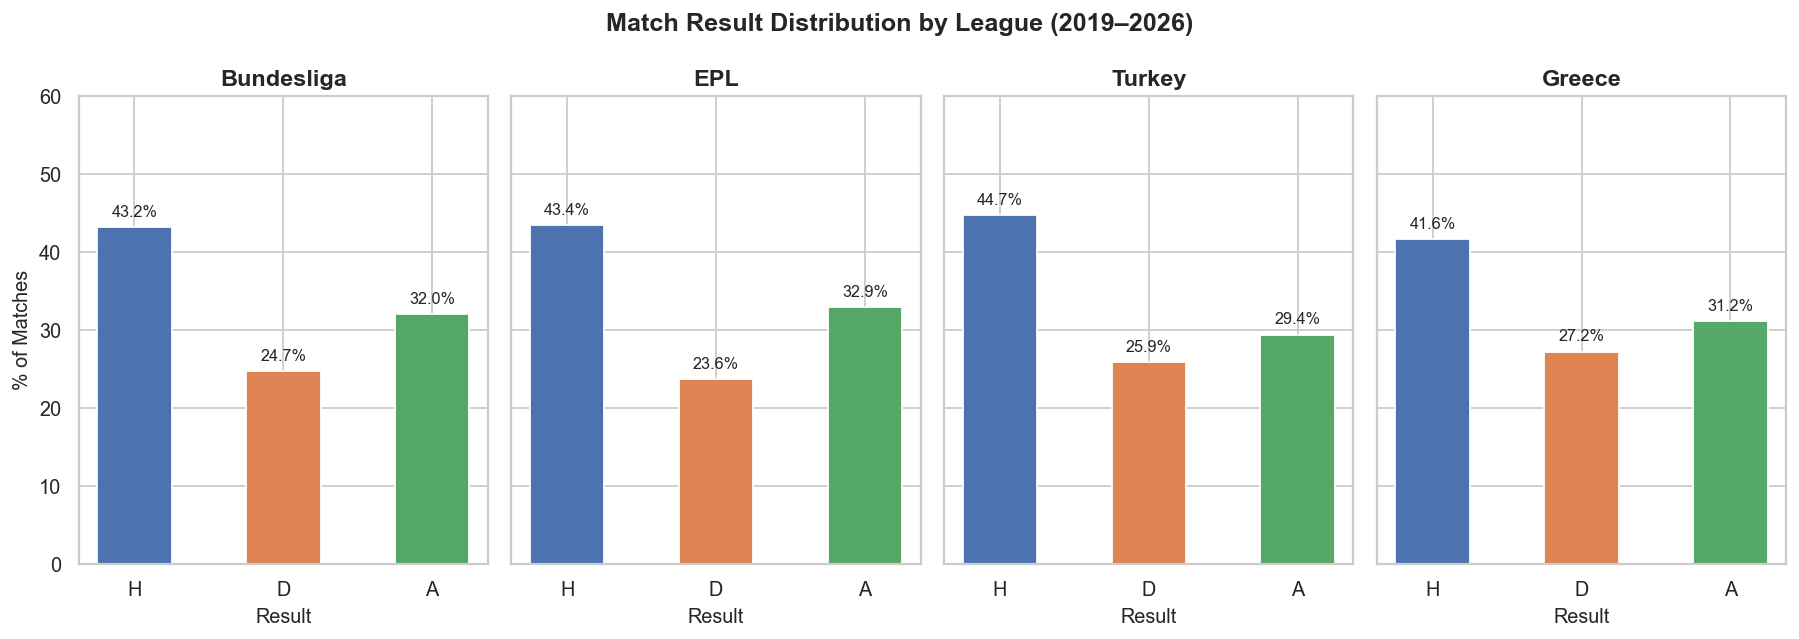

Saved: fig_01_result_distribution.png


In [38]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=True)

leagues = ['D1', 'E0', 'T1', 'G1']
league_names = {
    'D1': 'Bundesliga',
    'E0': 'EPL',
    'T1': 'Turkey',
    'G1': 'Greece'
}
colors = {'H': '#4C72B0', 'D': '#DD8452', 'A': '#55A868'}

for ax, league in zip(axes, leagues):
    data = master[master['league'] == league]['FTR'].value_counts(normalize=True) * 100
    data = data.reindex(['H', 'D', 'A'])
    bars = ax.bar(data.index, data.values, color=[colors[k] for k in data.index], width=0.5)
    ax.set_title(league_names[league], fontweight='bold')
    ax.set_xlabel('Result')
    ax.set_ylim(0, 60)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

axes[0].set_ylabel('% of Matches')
fig.suptitle('Match Result Distribution by League (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_01_result_distribution.png', bbox_inches='tight')
plt.show()
print("Saved: fig_01_result_distribution.png")


**Note:** 
All four leagues show the classic European football pattern — home wins ~42–45%, draws ~24–27%, away wins ~29–33%. The variation between leagues is minimal (< 3pp on any outcome).



**Baseline legitimacy check:** If one league showed dramatically skewed results (e.g. 60% home wins in Greece), that alone would be a red flag. The fact that all four leagues are consistent tells us:

- Result distributions are not where the manipulation signal hides
- We won't find integrity anomalies by looking at scorelines alone
- This validates our approach of looking at odds behaviour instead — bookmaker spreads, implied probabilities, and market disagreement are the right signals to chase



**Observations:** 
- Result distributions are broadly consistent across all four leagues (H: 42–45%, D: 24–27%, A: 29–33%). 

- This confirms that match outcome patterns alone are insufficient to detect integrity anomalies — validating the odds-based approach used in this project. 

- Turkey shows the strongest home advantage bias (44.7% H, 29.4% A).


### 4.2 Bookmaker spread by tier (H1 visual).

Max − Avg odds spread per match, comparing elite vs mid-tier leagues.

A higher spread indicates greater bookmaker disagreement — a key integrity signal.

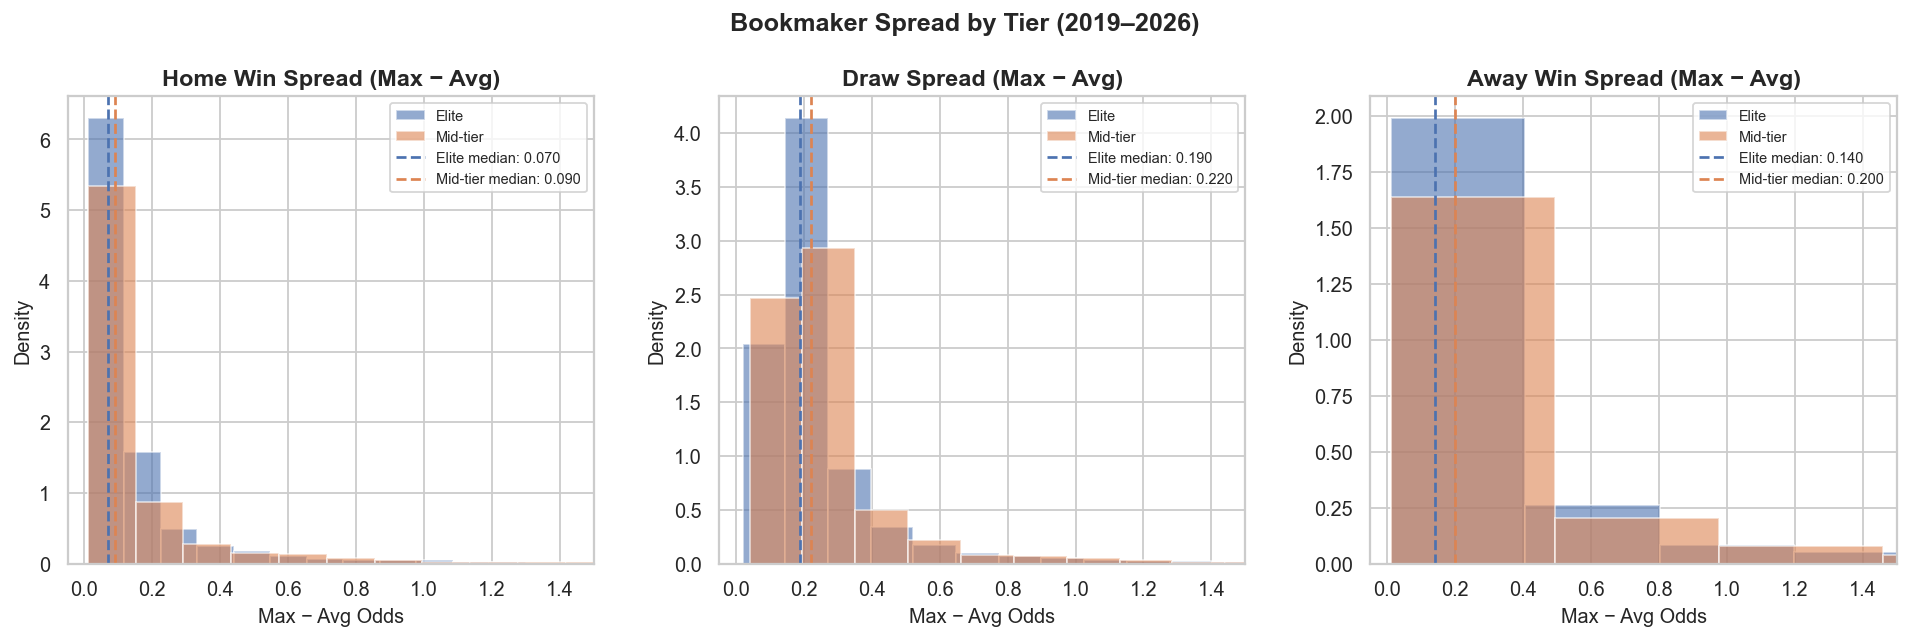

=== Bookmaker Spread Summary (median) ===

Home Win:
  Elite:    0.0700
  Mid-tier: 0.0900
  Mid-tier is +28.6% wider than elite

Draw:
  Elite:    0.1900
  Mid-tier: 0.2200
  Mid-tier is +15.8% wider than elite

Away Win:
  Elite:    0.1400
  Mid-tier: 0.2000
  Mid-tier is +42.9% wider than elite



In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

outcomes = ['H', 'D', 'A']
outcome_labels = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}

for ax, outcome in zip(axes, outcomes):
    col = f'bookmaker_spread_{outcome}'
    
    elite_data = master[master['tier'] == 'elite'][col].dropna()
    mid_data = master[master['tier'] == 'mid_tier'][col].dropna()
    
    ax.hist(elite_data, bins=60, alpha=0.6, label='Elite', color='#4C72B0', density=True)
    ax.hist(mid_data, bins=60, alpha=0.6, label='Mid-tier', color='#DD8452', density=True)
    
    ax.axvline(elite_data.median(), color='#4C72B0', linestyle='--', linewidth=1.5,
               label=f'Elite median: {elite_data.median():.3f}')
    ax.axvline(mid_data.median(), color='#DD8452', linestyle='--', linewidth=1.5,
               label=f'Mid-tier median: {mid_data.median():.3f}')
    
    ax.set_title(f'{outcome_labels[outcome]} Spread (Max − Avg)', fontweight='bold')
    ax.set_xlabel('Max − Avg Odds')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.05, 1.5)

fig.suptitle('Bookmaker Spread by Tier (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_02_bookmaker_spread_by_tier.png', bbox_inches='tight')
plt.show()

# Print summary stats
print("=== Bookmaker Spread Summary (median) ===\n")
for outcome in outcomes:
    col = f'bookmaker_spread_{outcome}'
    elite_med = master[master['tier'] == 'elite'][col].median()
    mid_med = master[master['tier'] == 'mid_tier'][col].median()
    diff_pct = ((mid_med - elite_med) / elite_med) * 100
    print(f"{outcome_labels[outcome]}:")
    print(f"  Elite:    {elite_med:.4f}")
    print(f"  Mid-tier: {mid_med:.4f}")
    print(f"  Mid-tier is {diff_pct:+.1f}% wider than elite\n")

**Observations (H1):** 

Mid-tier leagues (Turkey, Greece) show systematically wider bookmaker spreads than elite leagues (Bundesliga, EPL) across all three match outcomes. 

The away win spread is 42.9% wider in mid-tier leagues — the largest gap observed. 

Elite distributions are tightly concentrated near zero with minimal tail risk, while mid-tier distributions show significant right-skew with extreme outliers exceeding 1.0 odds units. 

This pattern is consistent with lower bookmaker confidence in mid-tier markets and forms the primary visual evidence for H1.

### 4.3 Implied probability sum by league (overround analysis)

The sum of implied probabilities (1/H + 1/D + 1/A) across all three outcomes should sum to >1.0.

The excess above 1.0 is the bookmaker's margin (overround). **Higher overround = bookmaker charging more = less efficient market.**

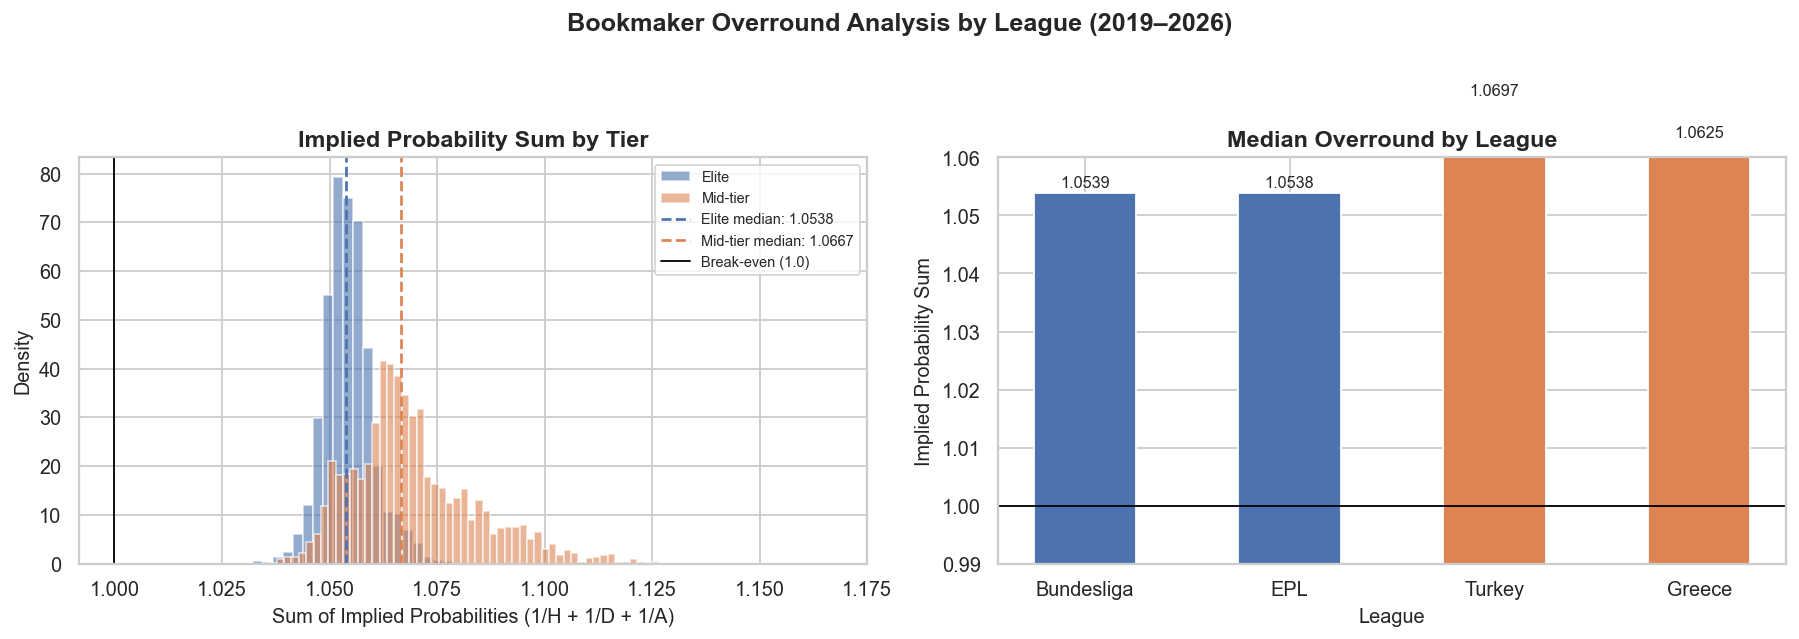

=== Overround Summary ===

Bundesliga: median=1.0539 → bookmaker margin=5.39%
EPL: median=1.0538 → bookmaker margin=5.38%
Turkey: median=1.0697 → bookmaker margin=6.97%
Greece: median=1.0625 → bookmaker margin=6.25%


In [40]:
# Drop rows where B365 nulls exist for this analysis
ips_data = master.dropna(subset=['implied_prob_sum'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — distribution by tier
elite_ips = ips_data[ips_data['tier'] == 'elite']['implied_prob_sum']
mid_ips = ips_data[ips_data['tier'] == 'mid_tier']['implied_prob_sum']

axes[0].hist(elite_ips, bins=60, alpha=0.6, label='Elite', color='#4C72B0', density=True)
axes[0].hist(mid_ips, bins=60, alpha=0.6, label='Mid-tier', color='#DD8452', density=True)
axes[0].axvline(elite_ips.median(), color='#4C72B0', linestyle='--', linewidth=1.5,
                label=f'Elite median: {elite_ips.median():.4f}')
axes[0].axvline(mid_ips.median(), color='#DD8452', linestyle='--', linewidth=1.5,
                label=f'Mid-tier median: {mid_ips.median():.4f}')
axes[0].axvline(1.0, color='black', linestyle='-', linewidth=1, label='Break-even (1.0)')
axes[0].set_title('Implied Probability Sum by Tier', fontweight='bold')
axes[0].set_xlabel('Sum of Implied Probabilities (1/H + 1/D + 1/A)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Chart 2 — median overround by league
overround_by_league = ips_data.groupby('league')['implied_prob_sum'].median()
overround_by_league = overround_by_league.reindex(['D1', 'E0', 'T1', 'G1'])
colors = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']
bars = axes[1].bar(
    ['Bundesliga', 'EPL', 'Turkey', 'Greece'],
    overround_by_league.values,
    color=colors, width=0.5
)
axes[1].axhline(1.0, color='black', linestyle='-', linewidth=1, label='Break-even (1.0)')
axes[1].set_title('Median Overround by League', fontweight='bold')
axes[1].set_xlabel('League')
axes[1].set_ylabel('Implied Probability Sum')
axes[1].set_ylim(0.99, 1.06)
for bar, val in zip(bars, overround_by_league.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Bookmaker Overround Analysis by League (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_03_implied_probability_sum.png', bbox_inches='tight')
plt.show()

# Summary stats
print("=== Overround Summary ===\n")
for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
    med = ips_data[ips_data['league'] == league]['implied_prob_sum'].median()
    margin_pct = (med - 1.0) * 100
    print(f"{name}: median={med:.4f} → bookmaker margin={margin_pct:.2f}%")

**Observation (Overround):** Mid-tier leagues charge systematically higher bookmaker margins than elite leagues. 

Turkey (6.97%) and Greece (6.25%) both significantly exceed Bundesliga (5.39%) and EPL (5.38%). 

The mid-tier distribution is wider and right-skewed, with extreme outliers approaching **17–18%** margin — values that have no legitimate explanation in an efficient market and will be primary targets for the anomaly detector.

### 4.4 Bookmaker spread by league (individual league breakdown)

Drilling into the spread by individual league to separate Turkey vs Greece within the mid-tier.

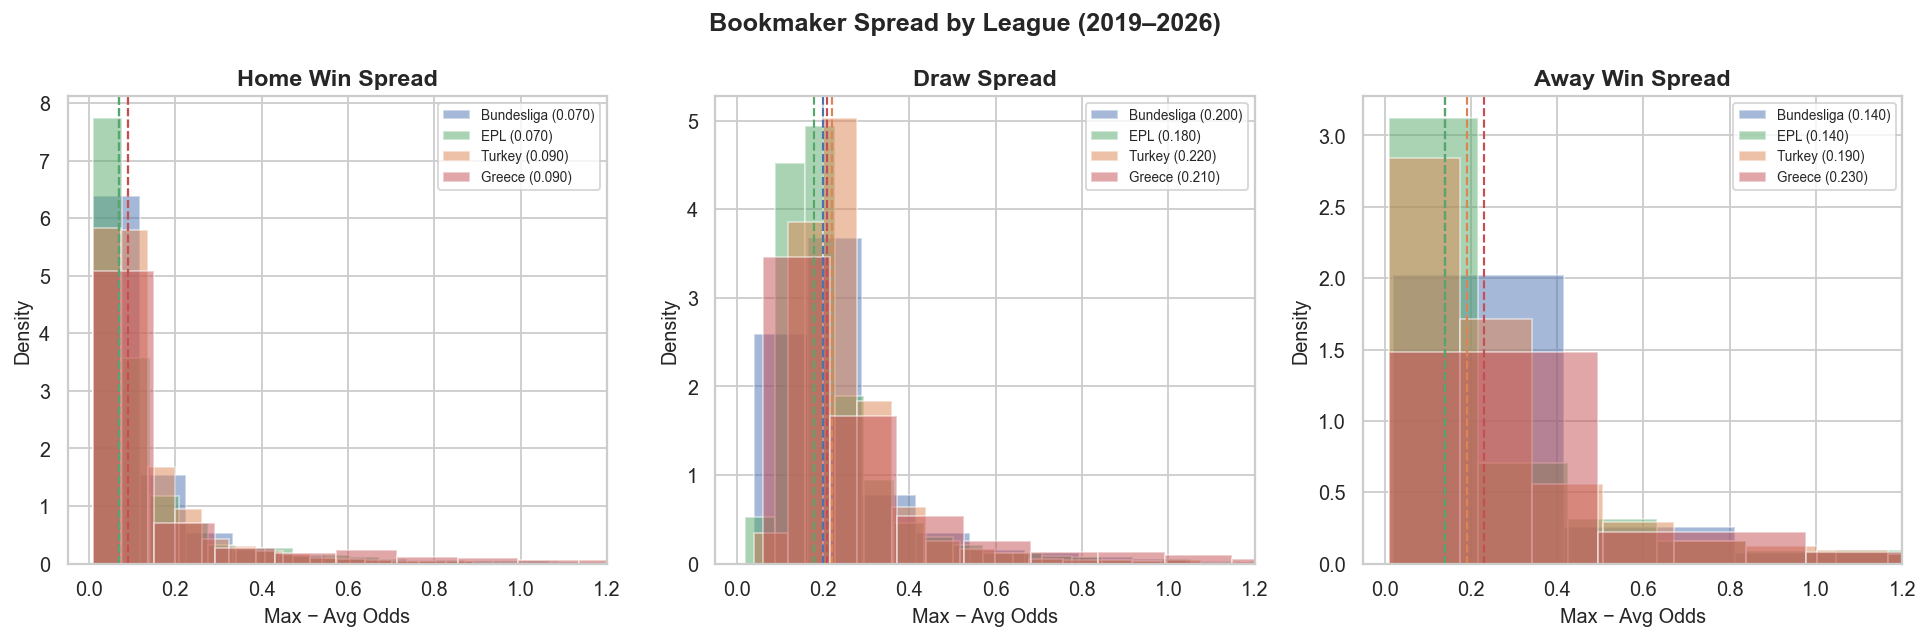

=== Median Spread by League ===

League           Home     Draw     Away     Mean
--------------------------------------------
Bundesliga     0.0700   0.2000   0.1400   0.1367
EPL            0.0700   0.1800   0.1400   0.1300
Turkey         0.0900   0.2200   0.1900   0.1667
Greece         0.0900   0.2100   0.2300   0.1767


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

outcomes = ['H', 'D', 'A']
outcome_labels = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
league_colors = {
    'D1': '#4C72B0',
    'E0': '#55A868',
    'T1': '#DD8452',
    'G1': '#C44E52'
}
league_names = {
    'D1': 'Bundesliga',
    'E0': 'EPL',
    'T1': 'Turkey',
    'G1': 'Greece'
}

for ax, outcome in zip(axes, outcomes):
    col = f'bookmaker_spread_{outcome}'
    
    medians = {}
    for league in ['D1', 'E0', 'T1', 'G1']:
        data = master[master['league'] == league][col].dropna()
        medians[league] = data.median()
        ax.hist(data, bins=60, alpha=0.5, label=f"{league_names[league]} ({data.median():.3f})",
                color=league_colors[league], density=True)
        ax.axvline(data.median(), color=league_colors[league], linestyle='--', linewidth=1.2)

    ax.set_title(f'{outcome_labels[outcome]} Spread', fontweight='bold')
    ax.set_xlabel('Max − Avg Odds')
    ax.set_ylabel('Density')
    ax.set_xlim(-0.05, 1.2)
    ax.legend(fontsize=7.5)

fig.suptitle('Bookmaker Spread by League (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_04_spread_by_league.png', bbox_inches='tight')
plt.show()

# Summary table
print("=== Median Spread by League ===\n")
print(f"{'League':<12} {'Home':>8} {'Draw':>8} {'Away':>8} {'Mean':>8}")
print("-" * 44)
for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
    h = master[master['league'] == league]['bookmaker_spread_H'].median()
    d = master[master['league'] == league]['bookmaker_spread_D'].median()
    a = master[master['league'] == league]['bookmaker_spread_A'].median()
    print(f"{name:<12} {h:>8.4f} {d:>8.4f} {a:>8.4f} {(h+d+a)/3:>8.4f}")

**Observation (League-level spread):** Individual league analysis reveals EPL as the most efficient market (mean spread 0.130), followed by Bundesliga (0.137), Turkey (0.167), and Greece (0.177). 

Greece's away win spread (0.230) is 64% wider than EPL — the largest single gap observed across all leagues and outcomes. 

This ranking is consistent with historical integrity records and suggests Greece warrants the closest scrutiny in the anomaly detection phase.

### 4.5 Seasonal trends in bookmaker spread

Tracking how bookmaker spread evolves across seasons for each league.
    
A downward trend = market becoming more efficient over time.

A spike in a specific season = potential integrity event or structural change.

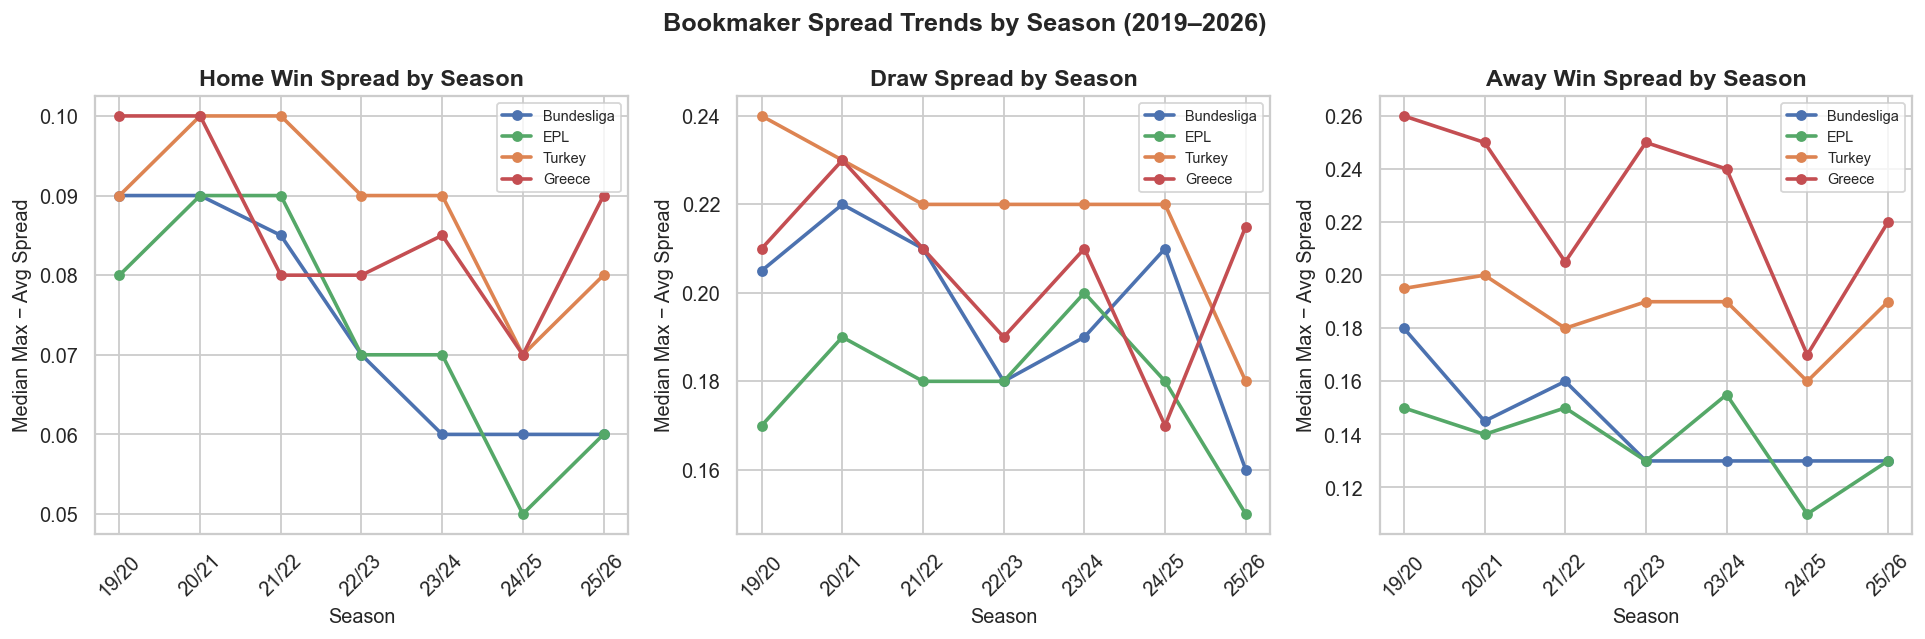

=== Median Away Win Spread by Season (most informative) ===

Season    Bundesliga         EPL      Turkey      Greece
--------------------------------------------------------
19/20         0.1800      0.1500      0.1950      0.2600
20/21         0.1450      0.1400      0.2000      0.2500
21/22         0.1600      0.1500      0.1800      0.2050
22/23         0.1300      0.1300      0.1900      0.2500
23/24         0.1300      0.1550      0.1900      0.2400
24/25         0.1300      0.1100      0.1600      0.1700
25/26         0.1300      0.1300      0.1900      0.2200


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

outcomes = ['H', 'D', 'A']
outcome_labels = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
season_labels = ['19/20', '20/21', '21/22', '22/23', '23/24', '24/25', '25/26']

for ax, outcome in zip(axes, outcomes):
    col = f'bookmaker_spread_{outcome}'
    
    for league, name, color in zip(
        ['D1', 'E0', 'T1', 'G1'],
        ['Bundesliga', 'EPL', 'Turkey', 'Greece'],
        ['#4C72B0', '#55A868', '#DD8452', '#C44E52']
    ):
        season_medians = (
            master[master['league'] == league]
            .groupby('season')[col]
            .median()
            .reindex(['1920','2021','2122','2223','2324','2425','2526'])
        )
        ax.plot(season_labels, season_medians.values, marker='o', 
                label=name, color=color, linewidth=2, markersize=5)

    ax.set_title(f'{outcome_labels[outcome]} Spread by Season', fontweight='bold')
    ax.set_xlabel('Season')
    ax.set_ylabel('Median Max − Avg Spread')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Bookmaker Spread Trends by Season (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_05_seasonal_trends.png', bbox_inches='tight')
plt.show()

# Print the numbers
print("=== Median Away Win Spread by Season (most informative) ===\n")
print(f"{'Season':<8}", end='')
for name in ['Bundesliga', 'EPL', 'Turkey', 'Greece']:
    print(f"{name:>12}", end='')
print()
print("-" * 56)

for season, label in zip(['1920','2021','2122','2223','2324','2425','2526'], season_labels):
    print(f"{label:<8}", end='')
    for league in ['D1', 'E0', 'T1', 'G1']:
        val = master[(master['league'] == league) & 
                     (master['season'] == season)]['bookmaker_spread_A'].median()
        print(f"{val:>12.4f}", end='')
    print()

**Observation (Seasonal Trends):** Elite leagues show consistent efficiency improvements over 7 seasons — EPL's away win spread fell from 0.150 to 0.110 by 24/25. 

Mid-tier leagues show no meaningful improvement — Turkey's away win spread (0.195 → 0.190) and Greece's (0.260 → 0.220) remain structurally elevated throughout the entire period. 

Greece's resistance to market efficiency improvement is the most notable pattern, with a brief dip in 24/25 immediately reverting in 25/26. 

The 19/20 Greece spike (0.260) coincides with the COVID-interrupted season and warrants contextual flagging.

### 4.6 End-of-season spread concentration (H4 visual)

Testing whether bookmaker spreads are higher in the final matches of the season.

Matches are grouped by their position in the season (matchday quintile).

Higher spread in the final quintile = potential integrity signal.

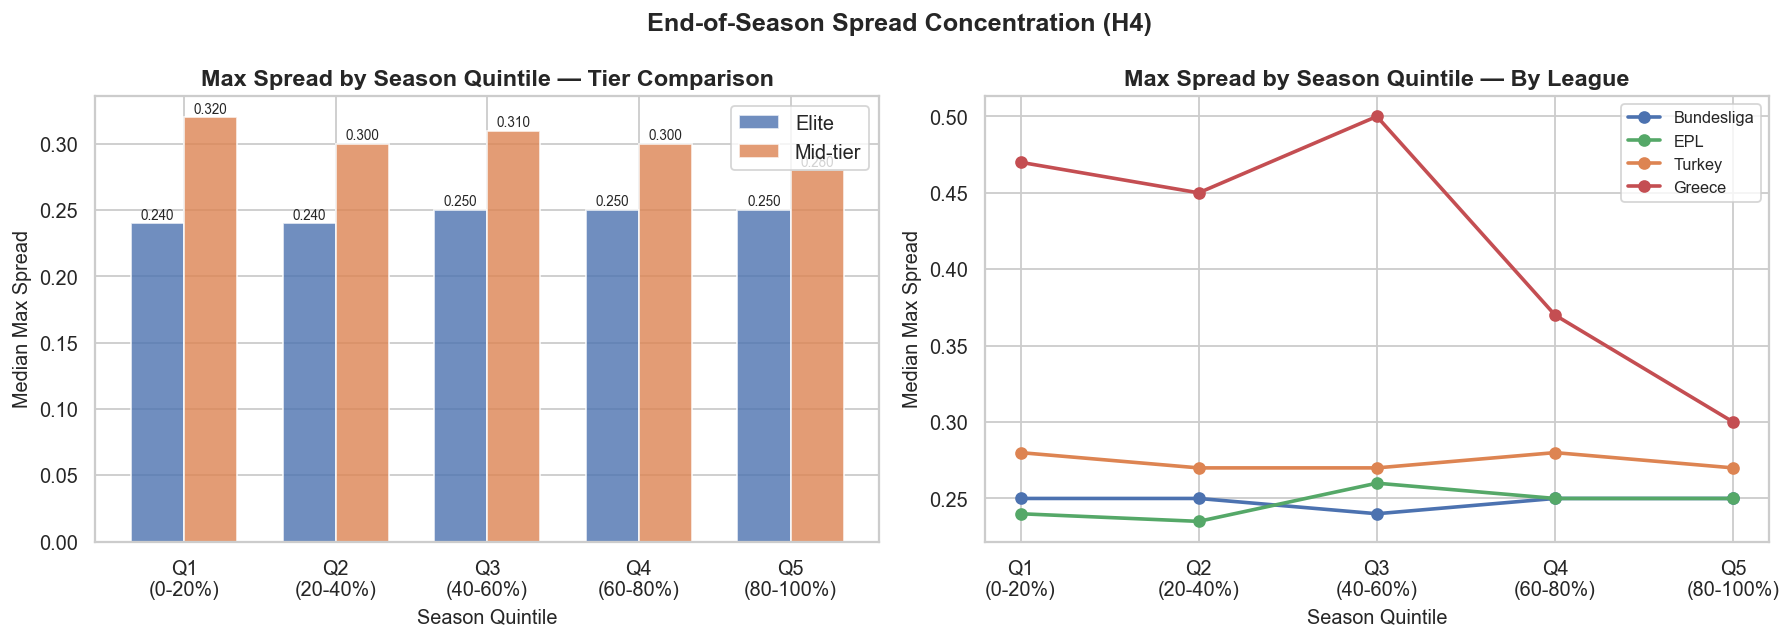

=== Median Max Spread by Quintile ===

Quintile       Bundesliga      EPL     Turkey     Greece
------------------------------------------------------
Q1              0.2500    0.2400    0.2800    0.4700
Q2              0.2500    0.2350    0.2700    0.4500
Q3              0.2400    0.2600    0.2700    0.5000
Q4              0.2500    0.2500    0.2800    0.3700
Q5              0.2500    0.2500    0.2700    0.3000

=== Q5 vs Q1 change (end vs start of season) ===

Bundesliga  : Q1=0.2500 → Q5=0.2500  (+0.0%)
EPL         : Q1=0.2400 → Q5=0.2500  (+4.2%)
Turkey      : Q1=0.2800 → Q5=0.2700  (-3.6%)
Greece      : Q1=0.4700 → Q5=0.3000  (-36.2%)


In [63]:
# Calculate matchday position within each league-season
# Note: Date already converted to datetime in Section 2

# Rank matches within each league-season by date
master['match_rank'] = master.groupby(['league', 'season'])['Date'].rank(method='first')
master['season_size'] = master.groupby(['league', 'season'])['Date'].transform('count')
master['season_pct'] = master['match_rank'] / master['season_size']

# Assign quintile (1=first 20% of season, 5=last 20% of season)
master['season_quintile'] = pd.cut(
    master['season_pct'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Q1\n(0-20%)', 'Q2\n(20-40%)', 'Q3\n(40-60%)', 'Q4\n(60-80%)', 'Q5\n(80-100%)']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — max_spread by quintile, elite vs mid-tier
quintile_tier = master.groupby(['season_quintile', 'tier'])['max_spread'].median().unstack()

x = range(5)
width = 0.35
quintile_labels = ['Q1\n(0-20%)', 'Q2\n(20-40%)', 'Q3\n(40-60%)', 'Q4\n(60-80%)', 'Q5\n(80-100%)']

bars1 = axes[0].bar([i - width/2 for i in x], quintile_tier['elite'], 
                     width, label='Elite', color='#4C72B0', alpha=0.8)
bars2 = axes[0].bar([i + width/2 for i in x], quintile_tier['mid_tier'], 
                     width, label='Mid-tier', color='#DD8452', alpha=0.8)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

axes[0].set_title('Max Spread by Season Quintile — Tier Comparison', fontweight='bold')
axes[0].set_xlabel('Season Quintile')
axes[0].set_ylabel('Median Max Spread')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(quintile_labels)
axes[0].legend()

# Chart 2 — max_spread by quintile, all 4 leagues
quintile_league = master.groupby(['season_quintile', 'league'])['max_spread'].median().unstack()

for league, name, color in zip(
    ['D1', 'E0', 'T1', 'G1'],
    ['Bundesliga', 'EPL', 'Turkey', 'Greece'],
    ['#4C72B0', '#55A868', '#DD8452', '#C44E52']
):
    axes[1].plot(quintile_labels, quintile_league[league].values,
                 marker='o', label=name, color=color, linewidth=2, markersize=6)

axes[1].set_title('Max Spread by Season Quintile — By League', fontweight='bold')
axes[1].set_xlabel('Season Quintile')
axes[1].set_ylabel('Median Max Spread')
axes[1].legend(fontsize=9)

fig.suptitle('End-of-Season Spread Concentration (H4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_06_end_of_season_concentration.png', bbox_inches='tight')
plt.show()

# Print summary table
print("=== Median Max Spread by Quintile ===\n")
print(f"{'Quintile':<12} {'Bundesliga':>12} {'EPL':>8} {'Turkey':>10} {'Greece':>10}")
print("-" * 54)
for q, label in zip(quintile_league.index, ['Q1','Q2','Q3','Q4','Q5']):
    print(f"{label:<12}", end='')
    for league in ['D1', 'E0', 'T1', 'G1']:
        print(f"{quintile_league.loc[q, league]:>10.4f}", end='')
    print()

# Q5 vs Q1 change
print("\n=== Q5 vs Q1 change (end vs start of season) ===\n")
for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
    q1 = quintile_league.loc['Q1\n(0-20%)', league]
    q5 = quintile_league.loc['Q5\n(80-100%)', league]
    change = ((q5 - q1) / q1) * 100
    print(f"{name:<12}: Q1={q1:.4f} → Q5={q5:.4f}  ({change:+.1f}%)")

**Observation (H4):** Contrary to expectations, end-of-season spread concentration is not observed in mid-tier leagues. 

Greece shows the opposite pattern — spreads peak in Q3 (mid-season, 0.500) and decline sharply toward Q5 (0.300), a -35.5% drop from Q1. 

Elite leagues show no meaningful seasonal variation. 

The Greek Super League's split-round format (top 6 vs bottom 10 in final phase) is a likely structural explanation. 

H4 is not supported in its original form — seasonal position alone is insufficient as an integrity signal. 

The anomaly detection model will treat season quintile as a contextual feature rather than a directional predictor.

## 5. Bookmaker Accuracy & Market Calibration

Additional analysis of bookmaker behaviour and game results.
All calibration analyses use closing odds with multiplicative normalisation.

### 5.1 Bookmaker accuracy — does the favourite win?

For each match, identify the bookmaker's favourite (lowest odds = highest implied probability).
Compare predicted favourite vs actual result across leagues and tiers.
Uses opening B365 odds — consistent with favourite win rate literature.



In [45]:
# Identify favourite for each match
def get_favourite(row):
    probs = {
        'H': 1 / row['B365H'],
        'D': 1 / row['B365D'],
        'A': 1 / row['B365A']
    }
    return max(probs, key=probs.get)

# Only use rows where B365 is available
accuracy_df = master.dropna(subset=['B365H', 'B365D', 'B365A']).copy()
accuracy_df['favourite'] = accuracy_df.apply(get_favourite, axis=1)
accuracy_df['favourite_won'] = accuracy_df['favourite'] == accuracy_df['FTR']

# Favourite type distribution
print("=== Favourite type distribution ===")
print(accuracy_df['favourite'].value_counts())
print(f"\nOverall favourite win rate: {accuracy_df['favourite_won'].mean()*100:.1f}%")

=== Favourite type distribution ===
favourite
H    5944
A    2940
D       4
Name: count, dtype: int64

Overall favourite win rate: 53.1%


#### Special case: draw as favourite

Only 4 matches in the dataset had a draw as the implied favourite.
All occurred in Greece and Turkey at end of season — investigated below.

In [46]:
# Finding 4 games where draw was the favorite per bookmakers

draw_favs = master.dropna(subset=['B365H', 'B365D', 'B365A']).copy()
draw_favs['favourite'] = draw_favs.apply(get_favourite, axis=1)
draw_favs = draw_favs[draw_favs['favourite'] == 'D']

cols = ['Date', 'HomeTeam', 'AwayTeam', 'league', 'season', 
        'B365H', 'B365D', 'B365A', 'FTR']
print(draw_favs[cols].to_string(index=False))

      Date         HomeTeam         AwayTeam league season  B365H  B365D  B365A FTR
2023-05-06         Giannina Asteras Tripolis     G1   2223    2.6   2.25   4.00   H
2024-04-27 Asteras Tripolis        OFI Crete     G1   2324    2.8   2.63   3.20   D
2024-05-18      Kayserispor        Konyaspor     T1   2324    3.0   2.40   3.10   D
2024-05-26        Konyaspor      Galatasaray     T1   2324    9.0   1.95   2.05   A


### 5.2 Market efficiency — calibration and favourite-longshot bias

Two linked analyses using normalised implied probabilities (margin removed).
Both use closing odds as the primary signal.

#### Methodology note: implied probability normalisation

Raw implied probabilities (1/odds) include the bookmaker's margin and sum to >1.0.
To compare predicted vs realised outcomes, we strip the margin by **multiplicative
normalisation** — dividing each outcome's implied probability by the row total so the
three outcomes sum to 1.0.

**Assumption:** this spreads the margin proportionally across all three outcomes.
Real bookmakers typically load disproportionate margin onto longshots, so proportional
normalisation may leave a small residual inflation on high-odds outcomes.

**Alternatives considered:** additive normalisation and Shin's method (the academic
standard for integrity analysis). Multiplicative normalisation is used here for
transparency; Shin's method is noted as a robustness check for future work.

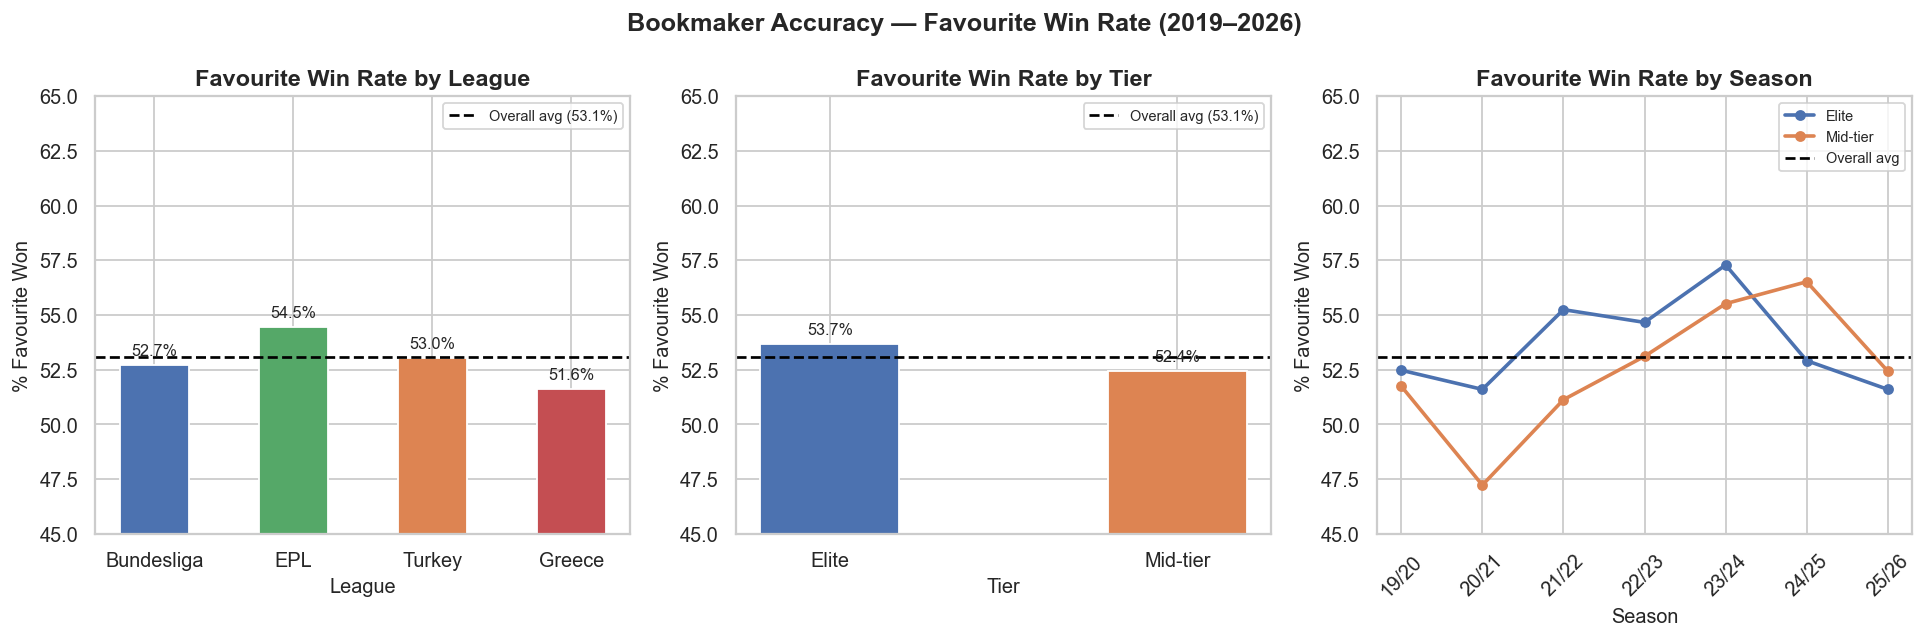

=== Favourite Win Rate by League ===

Bundesliga  : 52.7% (1129/2142 matches)
EPL         : 54.5% (1449/2660 matches)
Turkey      : 53.0% (1291/2435 matches)
Greece      : 51.6% (850/1647 matches)

=== By favourite type ===

Bundesliga   favourite=H: 53.6% (1393 matches)
EPL          favourite=H: 55.6% (1673 matches)
Turkey       favourite=H: 53.6% (1725 matches)
Greece       favourite=H: 50.5% (1153 matches)

Bundesliga   favourite=A: 51.1% (749 matches)
EPL          favourite=A: 52.5% (987 matches)
Turkey       favourite=A: 51.5% (710 matches)
Greece       favourite=A: 54.3% (494 matches)



In [47]:
# Remove the 4 draw-favourite matches
accuracy_df = accuracy_df[accuracy_df['favourite'] != 'D']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1 — favourite win rate by league
win_rate_league = accuracy_df.groupby('league')['favourite_won'].mean() * 100
win_rate_league = win_rate_league.reindex(['D1', 'E0', 'T1', 'G1'])
colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

bars = axes[0].bar(
    ['Bundesliga', 'EPL', 'Turkey', 'Greece'],
    win_rate_league.values,
    color=colors, width=0.5
)
axes[0].axhline(53.1, color='black', linestyle='--', linewidth=1.5, label='Overall avg (53.1%)')
axes[0].set_ylim(45, 65)
axes[0].set_title('Favourite Win Rate by League', fontweight='bold')
axes[0].set_xlabel('League')
axes[0].set_ylabel('% Favourite Won')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, win_rate_league.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Chart 2 — favourite win rate by tier
win_rate_tier = accuracy_df.groupby('tier')['favourite_won'].mean() * 100
bars2 = axes[1].bar(
    ['Elite', 'Mid-tier'],
    [win_rate_tier['elite'], win_rate_tier['mid_tier']],
    color=['#4C72B0', '#DD8452'], width=0.4
)
axes[1].axhline(53.1, color='black', linestyle='--', linewidth=1.5, label='Overall avg (53.1%)')
axes[1].set_ylim(45, 65)
axes[1].set_title('Favourite Win Rate by Tier', fontweight='bold')
axes[1].set_xlabel('Tier')
axes[1].set_ylabel('% Favourite Won')
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, [win_rate_tier['elite'], win_rate_tier['mid_tier']]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Chart 3 — favourite win rate by season and tier
win_rate_season = accuracy_df.groupby(['season', 'tier'])['favourite_won'].mean() * 100
season_labels = ['19/20', '20/21', '21/22', '22/23', '23/24', '24/25', '25/26']

for tier, color, label in zip(
    ['elite', 'mid_tier'],
    ['#4C72B0', '#DD8452'],
    ['Elite', 'Mid-tier']
):
    vals = win_rate_season.xs(tier, level='tier').reindex(
        ['1920','2021','2122','2223','2324','2425','2526']
    )
    axes[2].plot(season_labels, vals.values, marker='o',
                 color=color, label=label, linewidth=2, markersize=5)

axes[2].axhline(53.1, color='black', linestyle='--', linewidth=1.5, label='Overall avg')
axes[2].set_title('Favourite Win Rate by Season', fontweight='bold')
axes[2].set_xlabel('Season')
axes[2].set_ylabel('% Favourite Won')
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylim(45, 65)

fig.suptitle('Bookmaker Accuracy — Favourite Win Rate (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_07_favourite_win_rate.png', bbox_inches='tight')
plt.show()

# Summary stats
print("=== Favourite Win Rate by League ===\n")
for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
    rate = accuracy_df[accuracy_df['league'] == league]['favourite_won'].mean() * 100
    total = len(accuracy_df[accuracy_df['league'] == league])
    correct = accuracy_df[(accuracy_df['league'] == league) & 
                          (accuracy_df['favourite_won'])].shape[0]
    print(f"{name:<12}: {rate:.1f}% ({correct}/{total} matches)")

print(f"\n=== By favourite type ===\n")
for fav in ['H', 'A']:
    for league, name in zip(['D1','E0','T1','G1'], ['Bundesliga','EPL','Turkey','Greece']):
        subset = accuracy_df[(accuracy_df['league'] == league) & 
                             (accuracy_df['favourite'] == fav)]
        if len(subset) > 0:
            rate = subset['favourite_won'].mean() * 100
            print(f"{name:<12} favourite={fav}: {rate:.1f}% ({len(subset)} matches)")
    print()

**Observation (Bookmaker Accuracy):** EPL is the most accurately priced league (54.5% favourite win rate) while Greece is the least accurate (51.7%). 

The most striking finding is Greece's inverted home/away accuracy — home favourites win only 50.5% of the time (near random) while away favourites win 54.4%, the opposite pattern to all other leagues. This anomaly is consistent with weaker or less predictable home advantage in Greece and warrants further investigation in the anomaly detection phase. 

The COVID-affected 20/21 season shows a severe accuracy drop in mid-tier leagues (47.5%), confirming behind-closed-doors matches as a significant confound requiring contextual handling.

In [48]:
# Build long-format frame: each match -> 3 rows (H, D, A) with normalised implied prob
eff = master.dropna(subset=['B365H', 'B365D', 'B365A']).copy()

rows = []
for _, r in eff.iterrows():
    raw = {'H': 1/r['B365H'], 'D': 1/r['B365D'], 'A': 1/r['B365A']}
    total = sum(raw.values())  # the overround
    for outcome in ['H', 'D', 'A']:
        rows.append({
            'league': r['league'],
            'tier': r['tier'],
            'season': r['season'],
            'outcome': outcome,
            'implied_norm': raw[outcome] / total,   # margin removed
            'occurred': int(r['FTR'] == outcome)
        })

long_df = pd.DataFrame(rows)
print(f"Long-format rows: {len(long_df):,} (should be ~{len(eff)*3:,})")
print(f"\nMean normalised implied prob by outcome:")
print(long_df.groupby('outcome')['implied_norm'].mean().round(4))
print(f"\nActual occurrence rate by outcome:")
print(long_df.groupby('outcome')['occurred'].mean().round(4))

Long-format rows: 26,664 (should be ~26,664)

Mean normalised implied prob by outcome:
outcome
A    0.3161
D    0.2438
H    0.4401
Name: implied_norm, dtype: float64

Actual occurrence rate by outcome:
outcome
A    0.3141
D    0.2520
H    0.4338
Name: occurred, dtype: float64


### 5.3 Calibration curve — predicted vs realised probabilities

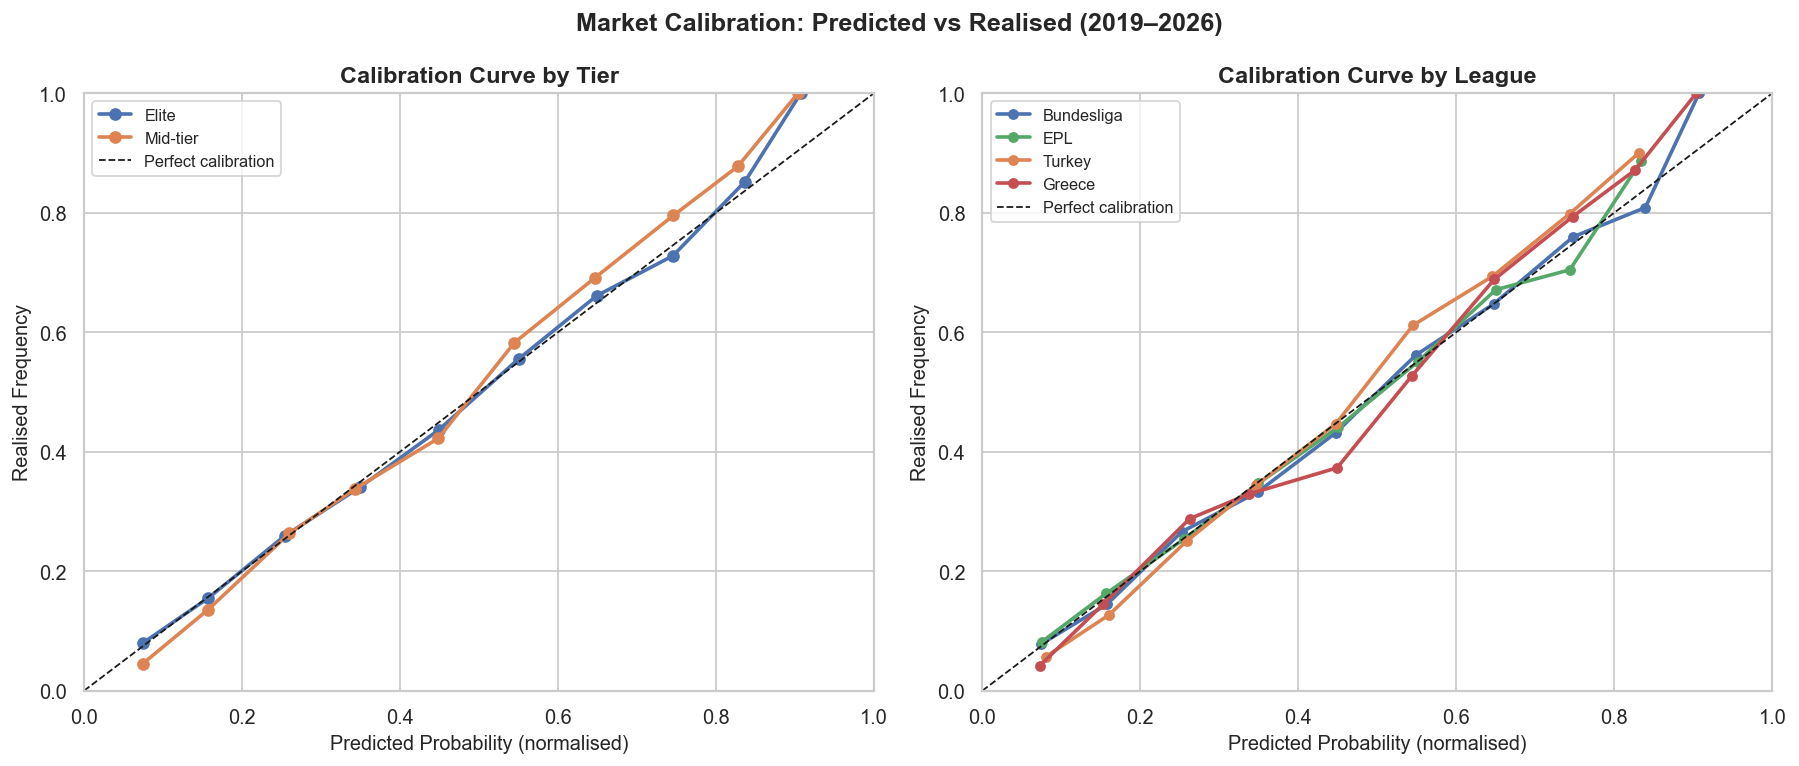

Points above diagonal = market underestimates that probability band
Points below diagonal = market overestimates that probability band


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bin into probability buckets and compute realised rate per bucket
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
bin_centers = [(bins[i] + bins[i+1])/2 for i in range(len(bins)-1)]

# Chart 1 — overall calibration by tier
for tier, color, label in zip(['elite', 'mid_tier'], ['#4C72B0', '#DD8452'], ['Elite', 'Mid-tier']):
    sub = long_df[long_df['tier'] == tier].copy()
    sub['bucket'] = pd.cut(sub['implied_norm'], bins=bins, labels=bin_centers)
    grouped = sub.groupby('bucket', observed=True).agg(
        predicted=('implied_norm', 'mean'),
        realised=('occurred', 'mean'),
        n=('occurred', 'size')
    ).dropna()
    axes[0].plot(grouped['predicted'], grouped['realised'], marker='o',
                 color=color, label=label, linewidth=2, markersize=6)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
axes[0].set_title('Calibration Curve by Tier', fontweight='bold')
axes[0].set_xlabel('Predicted Probability (normalised)')
axes[0].set_ylabel('Realised Frequency')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Chart 2 — calibration by league
for league, name, color in zip(['D1','E0','T1','G1'],
                                ['Bundesliga','EPL','Turkey','Greece'],
                                ['#4C72B0','#55A868','#DD8452','#C44E52']):
    sub = long_df[long_df['league'] == league].copy()
    sub['bucket'] = pd.cut(sub['implied_norm'], bins=bins, labels=bin_centers)
    grouped = sub.groupby('bucket', observed=True).agg(
        predicted=('implied_norm', 'mean'),
        realised=('occurred', 'mean')
    ).dropna()
    axes[1].plot(grouped['predicted'], grouped['realised'], marker='o',
                 color=color, label=name, linewidth=2, markersize=5)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
axes[1].set_title('Calibration Curve by League', fontweight='bold')
axes[1].set_xlabel('Predicted Probability (normalised)')
axes[1].set_ylabel('Realised Frequency')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

fig.suptitle('Market Calibration: Predicted vs Realised (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_08_calibration_curve.png', bbox_inches='tight')
plt.show()

# Points below the diagonal = overpredicted (outcome happens less than implied)
# Points above = underpredicted
print("Points above diagonal = market underestimates that probability band")
print("Points below diagonal = market overestimates that probability band")

**Observation (Calibration):** Both tiers and all four leagues hug the diagonal 
closely — bookmakers are well-calibrated overall. Mid-tier shows mild longshot 
underperformance at the bottom-left (0.05–0.20 band) and slight favourite 
outperformance at the top-right (0.75+), consistent with favourite-longshot bias. 
Individual league wiggles in the by-league chart should be interpreted cautiously 
due to small bucket sizes.

## 6. Drift Analysis — Opening to Closing Odds Movement

How much do odds move from open to close, and does the pattern differ between elite and mid-tier leagues?
Large drift = significant information arrived between open and close.
Pinnacle drift specifically = sharp/informed money movement.

### 6.1 B365 and Pinnacle drift distribution by tier

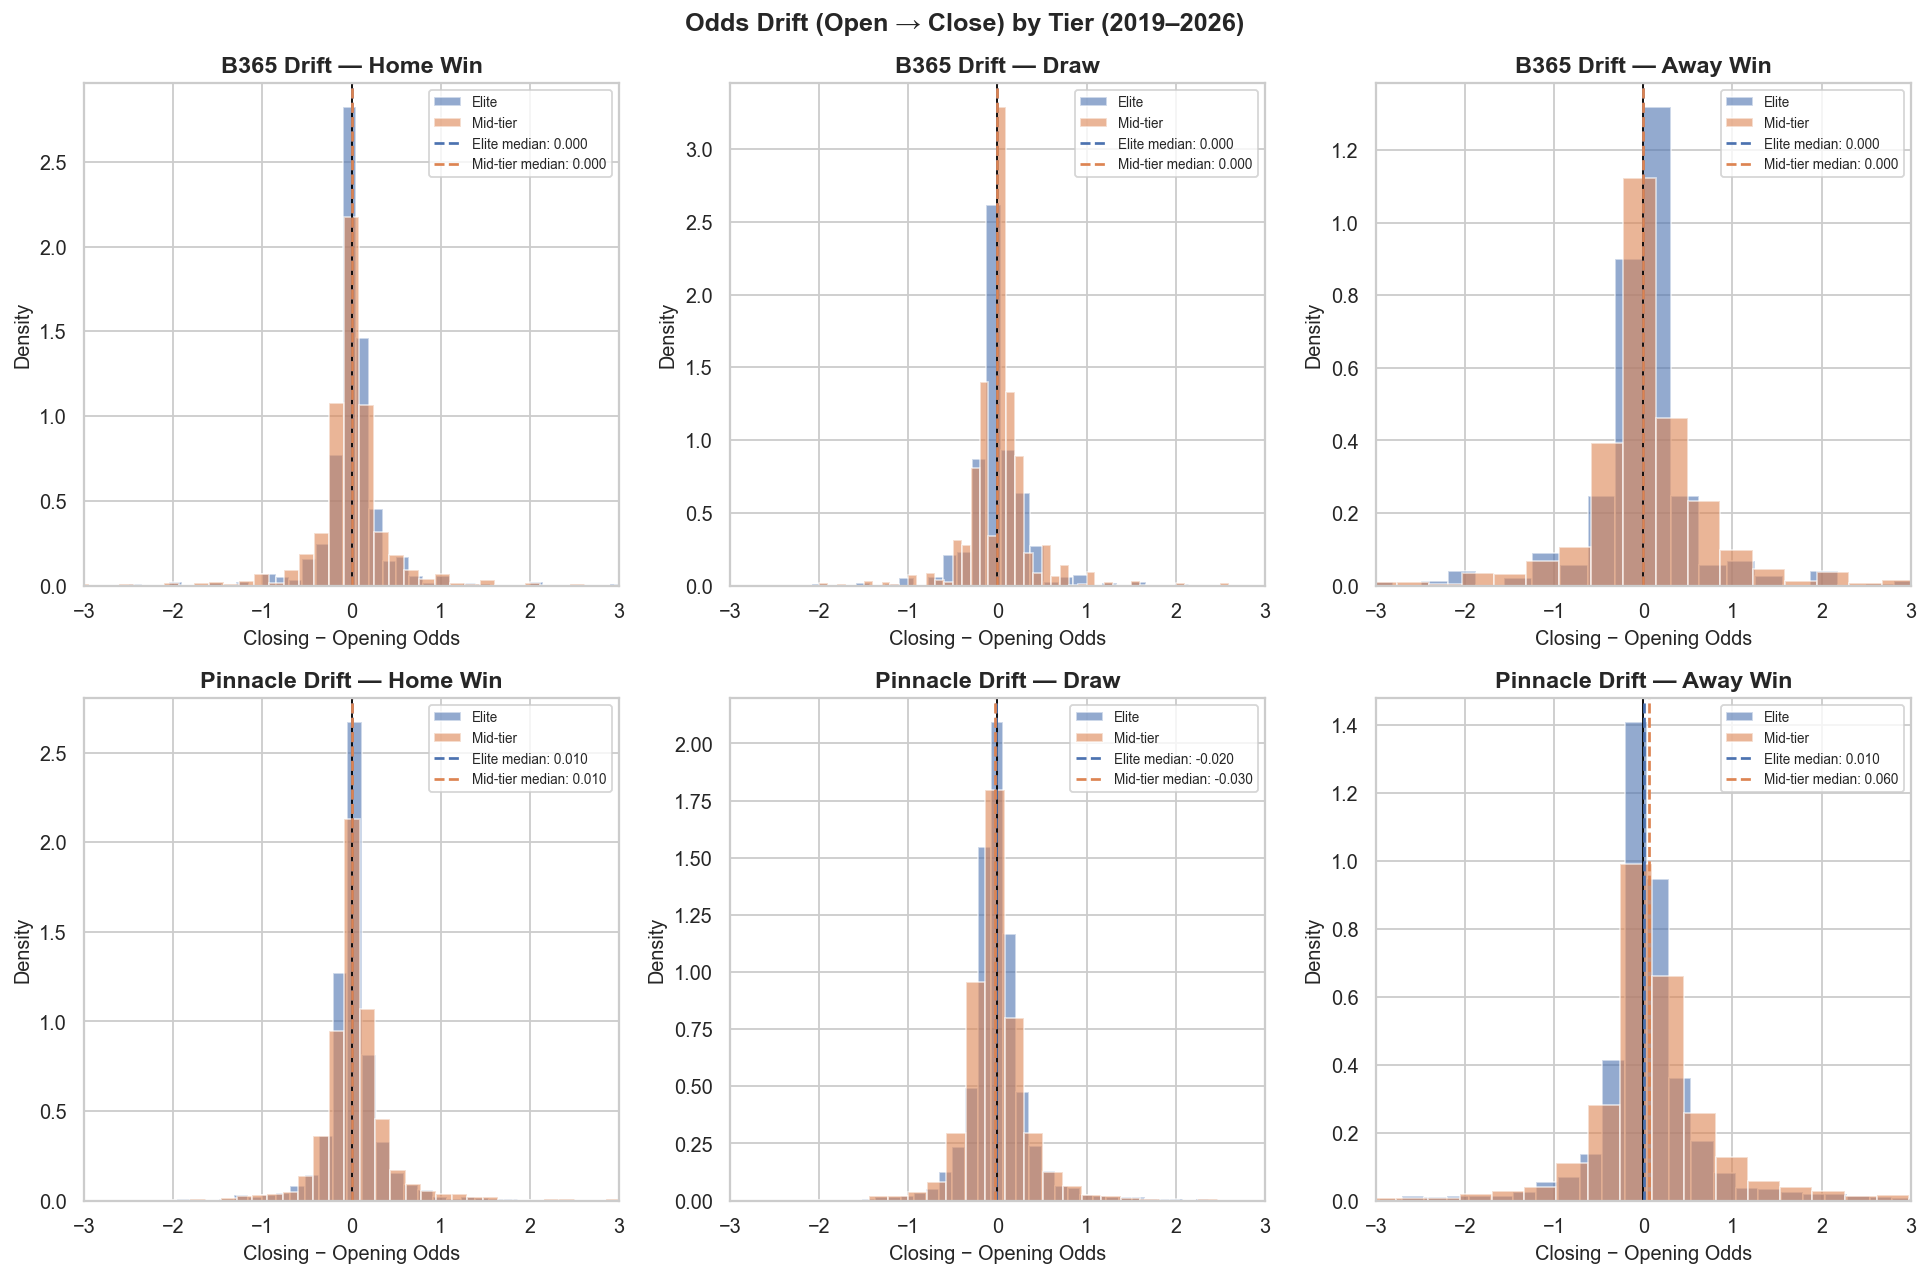

=== Drift Summary (median absolute drift) ===

Outcome    B365 Elite     B365 Mid     PS Elite       PS Mid
--------------------------------------------------------
Home           0.1000       0.1200       0.1000       0.1300
Draw           0.1000       0.1000       0.1200       0.1600
Away           0.1700       0.2500       0.1800       0.2600


In [50]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

outcomes = ['H', 'D', 'A']
outcome_labels = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}

for col_idx, outcome in enumerate(outcomes):
    # Row 1 — B365 drift
    b365_col = f'b365_drift_{outcome}'
    elite_b365 = master[master['tier'] == 'elite'][b365_col].dropna()
    mid_b365 = master[master['tier'] == 'mid_tier'][b365_col].dropna()
    
    axes[0, col_idx].hist(elite_b365, bins=80, alpha=0.6, color='#4C72B0', 
                          label='Elite', density=True)
    axes[0, col_idx].hist(mid_b365, bins=80, alpha=0.6, color='#DD8452', 
                          label='Mid-tier', density=True)
    axes[0, col_idx].axvline(0, color='black', linestyle='-', linewidth=1)
    axes[0, col_idx].axvline(elite_b365.median(), color='#4C72B0', 
                              linestyle='--', linewidth=1.5,
                              label=f'Elite median: {elite_b365.median():.3f}')
    axes[0, col_idx].axvline(mid_b365.median(), color='#DD8452', 
                              linestyle='--', linewidth=1.5,
                              label=f'Mid-tier median: {mid_b365.median():.3f}')
    axes[0, col_idx].set_title(f'B365 Drift — {outcome_labels[outcome]}', fontweight='bold')
    axes[0, col_idx].set_xlabel('Closing − Opening Odds')
    axes[0, col_idx].set_ylabel('Density')
    axes[0, col_idx].legend(fontsize=7.5)
    axes[0, col_idx].set_xlim(-3, 3)

    # Row 2 — Pinnacle drift
    ps_col = f'pinnacle_drift_{outcome}'
    elite_ps = master[master['tier'] == 'elite'][ps_col].dropna()
    mid_ps = master[master['tier'] == 'mid_tier'][ps_col].dropna()
    
    axes[1, col_idx].hist(elite_ps, bins=80, alpha=0.6, color='#4C72B0', 
                          label='Elite', density=True)
    axes[1, col_idx].hist(mid_ps, bins=80, alpha=0.6, color='#DD8452', 
                          label='Mid-tier', density=True)
    axes[1, col_idx].axvline(0, color='black', linestyle='-', linewidth=1)
    axes[1, col_idx].axvline(elite_ps.median(), color='#4C72B0', 
                              linestyle='--', linewidth=1.5,
                              label=f'Elite median: {elite_ps.median():.3f}')
    axes[1, col_idx].axvline(mid_ps.median(), color='#DD8452', 
                              linestyle='--', linewidth=1.5,
                              label=f'Mid-tier median: {mid_ps.median():.3f}')
    axes[1, col_idx].set_title(f'Pinnacle Drift — {outcome_labels[outcome]}', fontweight='bold')
    axes[1, col_idx].set_xlabel('Closing − Opening Odds')
    axes[1, col_idx].set_ylabel('Density')
    axes[1, col_idx].legend(fontsize=7.5)
    axes[1, col_idx].set_xlim(-3, 3)

fig.suptitle('Odds Drift (Open → Close) by Tier (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_08_drift_by_tier.png', bbox_inches='tight')
plt.show()

# Summary stats
print("=== Drift Summary (median absolute drift) ===\n")
print(f"{'Outcome':<8} {'B365 Elite':>12} {'B365 Mid':>12} {'PS Elite':>12} {'PS Mid':>12}")
print("-" * 56)
for outcome, label in zip(['H','D','A'], ['Home','Draw','Away']):
    b_e = master[master['tier']=='elite'][f'b365_drift_{outcome}'].abs().median()
    b_m = master[master['tier']=='mid_tier'][f'b365_drift_{outcome}'].abs().median()
    p_e = master[master['tier']=='elite'][f'pinnacle_drift_{outcome}'].abs().median()
    p_m = master[master['tier']=='mid_tier'][f'pinnacle_drift_{outcome}'].abs().median()
    print(f"{label:<8} {b_e:>12.4f} {b_m:>12.4f} {p_e:>12.4f} {p_m:>12.4f}")

In [51]:
print("=== B365 drift value inspection ===\n")

# Check how many rows have exactly 0 drift
for outcome in ['H', 'D', 'A']:
    col = f'b365_drift_{outcome}'
    exact_zero = (master[col] == 0.0).sum()
    near_zero = (master[col].abs() < 0.01).sum()
    total = master[col].notna().sum()
    print(f"b365_drift_{outcome}:")
    print(f"  Exactly 0.000:     {exact_zero:,} ({exact_zero/total*100:.1f}%)")
    print(f"  Within ±0.01:      {near_zero:,} ({near_zero/total*100:.1f}%)")
    print(f"  Non-zero:          {total-exact_zero:,} ({(total-exact_zero)/total*100:.1f}%)")
    print()

# Check a sample of raw opening vs closing values
print("=== Sample: B365 opening vs closing (first 10 rows) ===\n")
sample = master[['Date','HomeTeam','AwayTeam','league',
                 'B365H','B365CH','B365D','B365CD','B365A','B365CA']].head(10)
print(sample.to_string(index=False))

=== B365 drift value inspection ===

b365_drift_H:
  Exactly 0.000:     1,297 (14.6%)
  Within ±0.01:      1,298 (14.6%)
  Non-zero:          7,591 (85.4%)

b365_drift_D:
  Exactly 0.000:     2,617 (29.4%)
  Within ±0.01:      2,617 (29.4%)
  Non-zero:          6,271 (70.6%)

b365_drift_A:
  Exactly 0.000:     1,308 (14.7%)
  Within ±0.01:      1,308 (14.7%)
  Non-zero:          7,580 (85.3%)

=== Sample: B365 opening vs closing (first 10 rows) ===

      Date      HomeTeam           AwayTeam league  B365H  B365CH  B365D  B365CD  B365A  B365CA
2019-08-16 Bayern Munich             Hertha     D1   1.14    1.14   8.00    8.00  15.00   15.00
2019-08-17      Dortmund           Augsburg     D1   1.20    1.12   7.00    8.00  13.00   26.00
2019-08-17      Freiburg              Mainz     D1   2.25    2.55   3.25    3.30   3.40    2.70
2019-08-17    Leverkusen          Paderborn     D1   1.25    1.22   6.00    6.50  12.00   11.00
2019-08-17 Werder Bremen Fortuna Dusseldorf     D1   1.75    1.66 

### 6.2 Drift by league — separating Turkey vs Greece

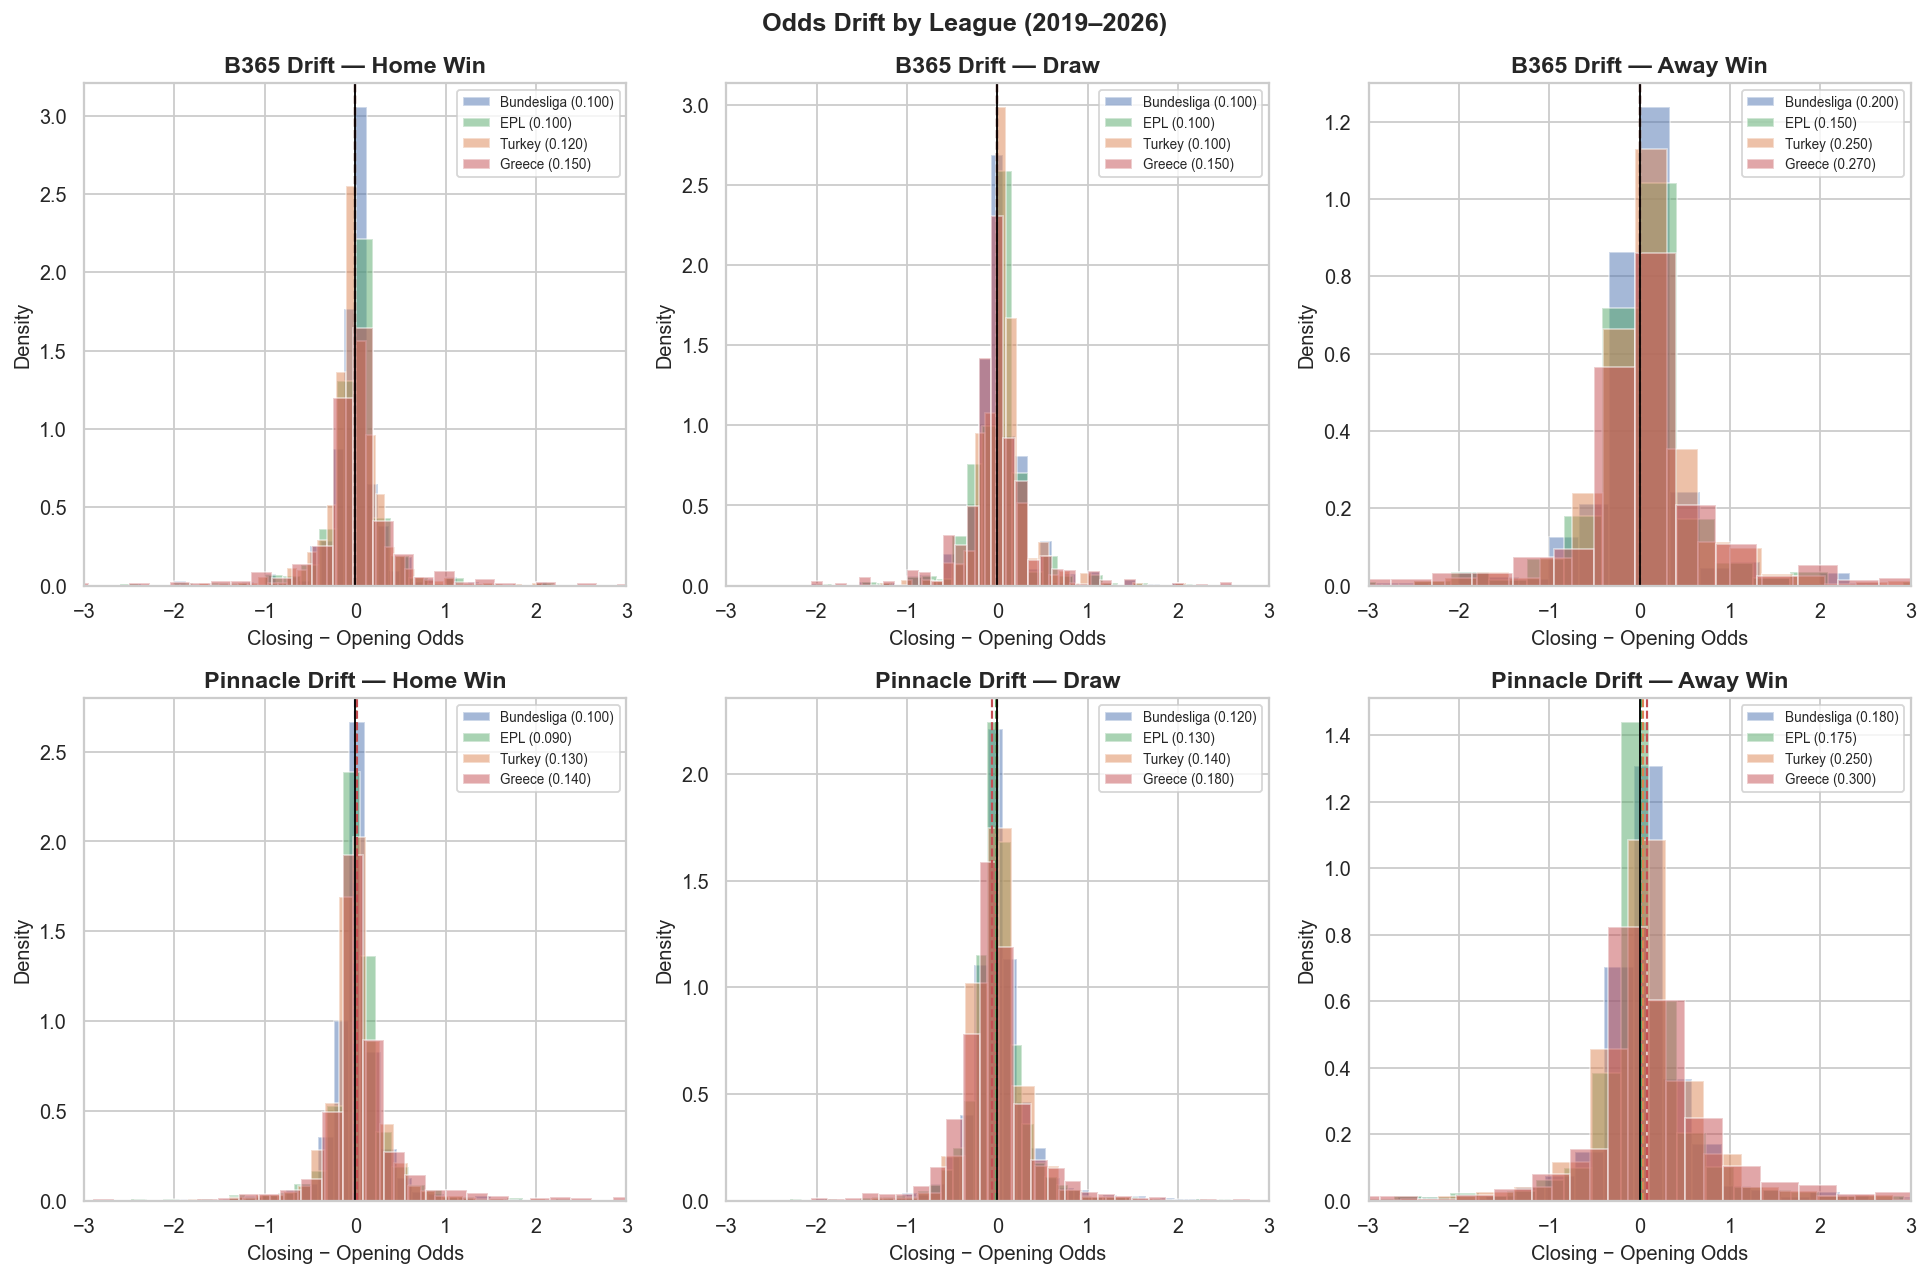

=== Absolute Median Drift by League ===

League         B365-H   B365-D   B365-A     PS-H     PS-D     PS-A
------------------------------------------------------------
Bundesliga      0.100    0.100    0.200    0.100    0.120    0.180
EPL             0.100    0.100    0.150    0.090    0.130    0.175
Turkey          0.120    0.100    0.250    0.130    0.140    0.250
Greece          0.150    0.150    0.270    0.140    0.180    0.300


In [52]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

outcomes = ['H', 'D', 'A']
outcome_labels = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
league_colors = {
    'D1': '#4C72B0',
    'E0': '#55A868',
    'T1': '#DD8452',
    'G1': '#C44E52'
}
league_names = {
    'D1': 'Bundesliga',
    'E0': 'EPL',
    'T1': 'Turkey',
    'G1': 'Greece'
}

for col_idx, outcome in enumerate(outcomes):
    b365_col = f'b365_drift_{outcome}'
    ps_col = f'pinnacle_drift_{outcome}'

    # Row 1 — B365 drift by league
    for league in ['D1', 'E0', 'T1', 'G1']:
        data = master[master['league'] == league][b365_col].dropna()
        axes[0, col_idx].hist(data, bins=60, alpha=0.5, density=True,
                              color=league_colors[league],
                              label=f"{league_names[league]} ({data.abs().median():.3f})")
        axes[0, col_idx].axvline(data.median(), color=league_colors[league],
                                  linestyle='--', linewidth=1.2)

    axes[0, col_idx].axvline(0, color='black', linestyle='-', linewidth=1)
    axes[0, col_idx].set_title(f'B365 Drift — {outcome_labels[outcome]}', fontweight='bold')
    axes[0, col_idx].set_xlabel('Closing − Opening Odds')
    axes[0, col_idx].set_ylabel('Density')
    axes[0, col_idx].legend(fontsize=7.5)
    axes[0, col_idx].set_xlim(-3, 3)

    # Row 2 — Pinnacle drift by league
    for league in ['D1', 'E0', 'T1', 'G1']:
        data = master[master['league'] == league][ps_col].dropna()
        axes[1, col_idx].hist(data, bins=60, alpha=0.5, density=True,
                              color=league_colors[league],
                              label=f"{league_names[league]} ({data.abs().median():.3f})")
        axes[1, col_idx].axvline(data.median(), color=league_colors[league],
                                  linestyle='--', linewidth=1.2)

    axes[1, col_idx].axvline(0, color='black', linestyle='-', linewidth=1)
    axes[1, col_idx].set_title(f'Pinnacle Drift — {outcome_labels[outcome]}', fontweight='bold')
    axes[1, col_idx].set_xlabel('Closing − Opening Odds')
    axes[1, col_idx].set_ylabel('Density')
    axes[1, col_idx].legend(fontsize=7.5)
    axes[1, col_idx].set_xlim(-3, 3)

fig.suptitle('Odds Drift by League (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_09_drift_by_league.png', bbox_inches='tight')
plt.show()

# Summary table — absolute median drift by league
print("=== Absolute Median Drift by League ===\n")
print(f"{'League':<12} {'B365-H':>8} {'B365-D':>8} {'B365-A':>8} {'PS-H':>8} {'PS-D':>8} {'PS-A':>8}")
print("-" * 60)
for league, name in zip(['D1','E0','T1','G1'], 
                         ['Bundesliga','EPL','Turkey','Greece']):
    row = [name]
    for bookmaker in ['b365', 'pinnacle']:
        for outcome in ['H', 'D', 'A']:
            col = f'{bookmaker}_drift_{outcome}'
            val = master[master['league'] == league][col].abs().median()
            row.append(f'{val:.3f}')
    print(f"{row[0]:<12} {row[1]:>8} {row[2]:>8} {row[3]:>8} {row[4]:>8} {row[5]:>8} {row[6]:>8}")

**Observation (Drift by League):** Individual league drift analysis confirms the 
efficiency ranking EPL > Bundesliga > Turkey > Greece across all outcomes and both 
bookmakers. Greece's Pinnacle away win drift (0.300) is the highest value in the 
entire dataset — 71% wider than EPL (0.175) — indicating maximum sharp money activity 
on Greek away outcomes. The consistency of this ranking across spread, overround, 
calibration, and drift analyses provides robust multi-signal evidence for H1. 
Turkey and Greece show meaningful separation on Pinnacle drift (0.250 vs 0.300), 
confirming Greece as the least efficient market in the dataset.

### 6.3 Opening vs closing spread comparison

Does bookmaker disagreement increase or decrease from open to close?
Increasing spread toward close = unusual — normally markets converge as more information arrives.
A match where closing spread > opening spread is a potential integrity flag.

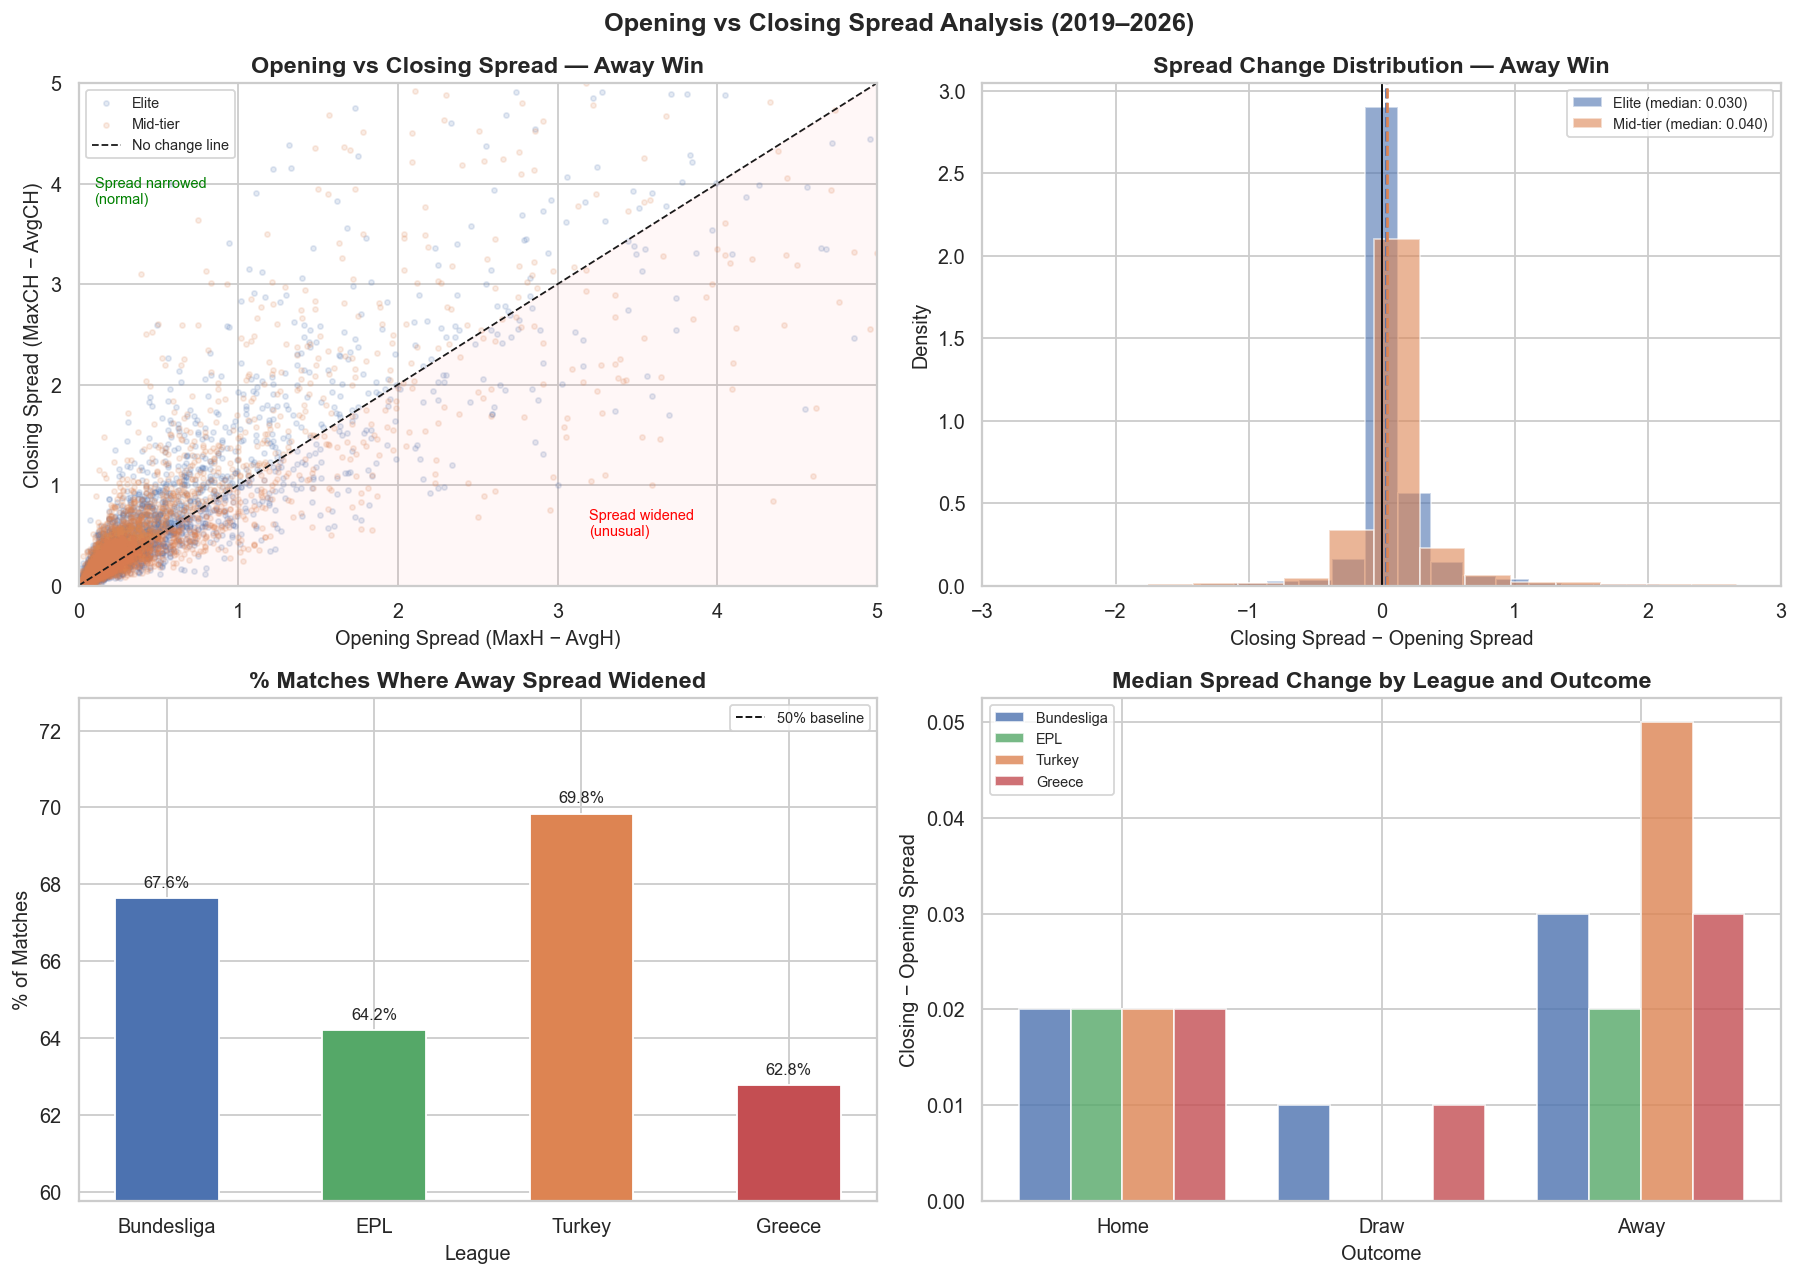

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 — opening vs closing spread by tier (away win)
for tier, color, label in zip(['elite','mid_tier'], ['#4C72B0','#DD8452'], ['Elite','Mid-tier']):
    sub = master[master['tier'] == tier]
    axes[0,0].scatter(sub['opening_spread_A'], sub['closing_spread_A'],
                      alpha=0.15, s=8, color=color, label=label)

axes[0,0].plot([0,10],[0,10], 'k--', linewidth=1, label='No change line')
axes[0,0].set_xlim(0, 5)
axes[0,0].set_ylim(0, 5)
axes[0,0].set_title('Opening vs Closing Spread — Away Win', fontweight='bold')
axes[0,0].set_xlabel('Opening Spread (MaxH − AvgH)')
axes[0,0].set_ylabel('Closing Spread (MaxCH − AvgCH)')
axes[0,0].legend(fontsize=8, loc='upper left')
axes[0,0].fill_between([0,5],[0,0],[0,5], alpha=0.03, color='red')
# FIX 1 — moved text positions to avoid overlap
axes[0,0].text(3.2, 0.5, 'Spread widened\n(unusual)', fontsize=8, color='red')
axes[0,0].text(0.1, 3.8, 'Spread narrowed\n(normal)', fontsize=8, color='green')

# Chart 2 — spread change distribution by tier
for tier, color, label in zip(['elite','mid_tier'], ['#4C72B0','#DD8452'], ['Elite','Mid-tier']):
    data = master[master['tier'] == tier]['spread_change_A'].dropna()
    axes[0,1].hist(data, bins=80, alpha=0.6, density=True, color=color,
                   label=f'{label} (median: {data.median():.3f})')
    axes[0,1].axvline(data.median(), color=color, linestyle='--', linewidth=1.5)

axes[0,1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[0,1].set_title('Spread Change Distribution — Away Win', fontweight='bold')
axes[0,1].set_xlabel('Closing Spread − Opening Spread')
axes[0,1].set_ylabel('Density')
axes[0,1].legend(fontsize=8)
axes[0,1].set_xlim(-3, 3)

# Chart 3 — % of matches where spread widened, by league
print_data = {}
for league, name in zip(['D1','E0','T1','G1'],
                         ['Bundesliga','EPL','Turkey','Greece']):
    pct_widened = (master[master['league']==league]['spread_change_A'] > 0).mean() * 100
    print_data[name] = pct_widened

colors = ['#4C72B0','#55A868','#DD8452','#C44E52']
bars = axes[1,0].bar(print_data.keys(), print_data.values(), color=colors, width=0.5)
axes[1,0].axhline(50, color='black', linestyle='--', linewidth=1, label='50% baseline')

# FIX 2 — tighter y-axis to show differences between leagues
min_val = min(print_data.values())
max_val = max(print_data.values())
axes[1,0].set_ylim(min_val - 3, max_val + 3)

axes[1,0].set_title('% Matches Where Away Spread Widened', fontweight='bold')
axes[1,0].set_xlabel('League')
axes[1,0].set_ylabel('% of Matches')
axes[1,0].legend(fontsize=8)
for bar, val in zip(bars, print_data.values()):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                   f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Chart 4 — median spread change by league and outcome
outcomes = ['H', 'D', 'A']
outcome_labels_short = ['Home', 'Draw', 'Away']
x = range(3)
width = 0.2

for i, (league, name, color) in enumerate(zip(
    ['D1','E0','T1','G1'],
    ['Bundesliga','EPL','Turkey','Greece'],
    ['#4C72B0','#55A868','#DD8452','#C44E52']
)):
    medians = [master[master['league']==league][f'spread_change_{o}'].median()
               for o in outcomes]
    axes[1,1].bar([xi + i*width for xi in x], medians, width,
                  label=name, color=color, alpha=0.8)

axes[1,1].axhline(0, color='black', linestyle='-', linewidth=1)
axes[1,1].set_title('Median Spread Change by League and Outcome', fontweight='bold')
axes[1,1].set_xlabel('Outcome')
axes[1,1].set_ylabel('Closing − Opening Spread')
axes[1,1].set_xticks([xi + 1.5*width for xi in x])
axes[1,1].set_xticklabels(outcome_labels_short)
axes[1,1].legend(fontsize=8)

fig.suptitle('Opening vs Closing Spread Analysis (2019–2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_10_spread_change.png', bbox_inches='tight')
plt.show()

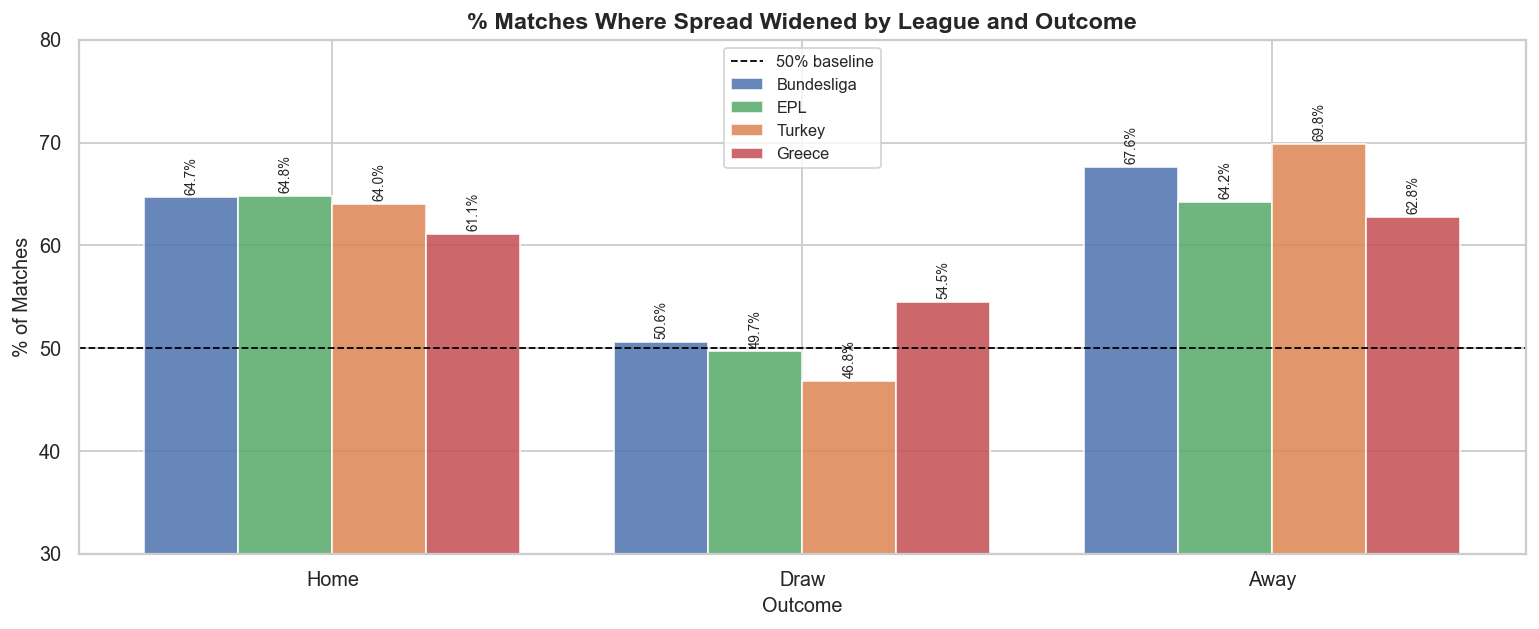

=== % Matches Where Spread Widened — All Outcomes ===

League           Home     Draw     Away
------------------------------------
Bundesliga      64.7%    50.6%    67.6%
EPL             64.8%    49.7%    64.2%
Turkey          64.0%    46.8%    69.8%
Greece          61.1%    54.5%    62.8%


In [55]:
fig, ax = plt.subplots(figsize=(12, 5))

outcomes = ['H', 'D', 'A']
outcome_labels_short = ['Home', 'Draw', 'Away']
leagues = ['D1', 'E0', 'T1', 'G1']
league_names = ['Bundesliga', 'EPL', 'Turkey', 'Greece']
colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

x = range(len(outcomes))
width = 0.2

for i, (league, name, color) in enumerate(zip(leagues, league_names, colors)):
    pcts = []
    for outcome in outcomes:
        pct = (master[master['league'] == league][f'spread_change_{outcome}'] > 0).mean() * 100
        pcts.append(pct)
    bars = ax.bar([xi + i*width for xi in x], pcts, width,
                  label=name, color=color, alpha=0.85)
    for bar, val in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5, rotation=90)

ax.axhline(50, color='black', linestyle='--', linewidth=1, label='50% baseline')
ax.set_ylim(30, 80)
ax.set_title('% Matches Where Spread Widened by League and Outcome', fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('% of Matches')
ax.set_xticks([xi + 1.5*width for xi in x])
ax.set_xticklabels(outcome_labels_short, fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/fig_10b_spread_widened_all_outcomes.png', bbox_inches='tight')
plt.show()

# Full summary table
print("=== % Matches Where Spread Widened — All Outcomes ===\n")
print(f"{'League':<12} {'Home':>8} {'Draw':>8} {'Away':>8}")
print("-" * 36)
for league, name in zip(leagues, league_names):
    row = []
    for outcome in outcomes:
        pct = (master[master['league'] == league][f'spread_change_{outcome}'] > 0).mean() * 100
        row.append(pct)
    print(f"{name:<12} {row[0]:>7.1f}% {row[1]:>7.1f}% {row[2]:>7.1f}%")

**Observation (Opening vs Closing Spread):** Bookmaker spreads widen from open to 
close in the majority of matches across all leagues — 63–70% for away outcomes, 
61–65% for home outcomes, ~50% for draws. This is counterintuitive: efficient markets 
should converge as kickoff approaches. Turkey has the highest away spread widening 
rate (69.8%) and the largest median away spread change (+0.050), suggesting Turkish 
away outcomes attract the most active late bookmaker repricing. Greece has the lowest 
widening rate (62.8%) but the widest absolute spreads — meaning Greece starts wide 
and stays wide, while Turkey actively widens further. EPL is the most stable market 
(64.2%, median change +0.020). All leagues show positive median spread change on away 
outcomes, confirming systematic market divergence rather than convergence as kickoff 
approaches.

**Observation (Spread Widening — All Outcomes):** Home spread widening is uniform 
across all leagues (~62–65%), offering no discriminative signal. Draw spread widening 
reveals the sharpest league divergence in this analysis: Turkey (46.8%) shows 
systematic draw spread narrowing — bookmakers converge on draw prices pre-kickoff — 
while Greece (54.5%) shows systematic widening, suggesting persistent draw pricing 
uncertainty. This reversal of the usual Turkey/Greece ranking on draw outcomes warrants 
specific attention in the anomaly detection phase. Away spread widening follows the 
expected pattern: Turkey highest (69.8%), Greece lowest (62.8%), confirming Turkish 
away outcomes attract the most active late market repricing.

### 6.4 Favourite-longshot bias (closing odds)

Buckets matches by implied probability and compares predicted vs realised win rate.
In an efficient market the two should match. Systematic deviation = bias.
Favourite-longshot bias: longshots win less often than implied, favourites win more often.

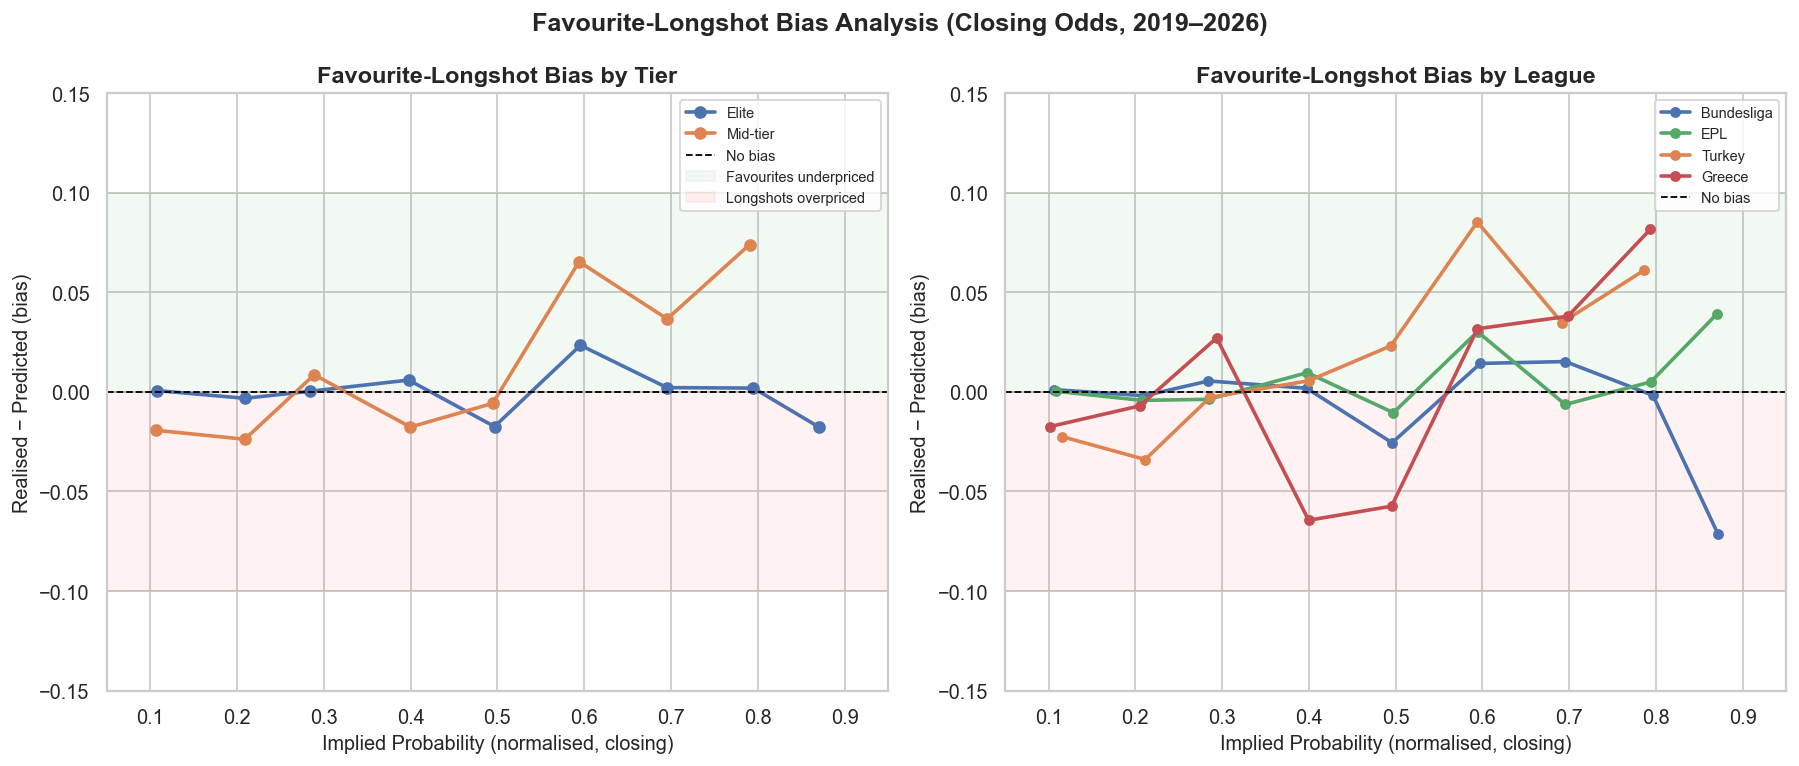

=== Bias (Realised − Predicted) by Tier and Probability Band ===

Band              Elite   Mid-tier       Diff
--------------------------------------------
0.075           +0.0007    -0.0193    -0.0200
0.2             -0.0032    -0.0238    -0.0206
0.3             +0.0003    +0.0086    +0.0083
0.4             +0.0059    -0.0176    -0.0235
0.5             -0.0174    -0.0058    +0.0116
0.6000000000000001    +0.0234    +0.0654    +0.0420
0.7             +0.0022    +0.0366    +0.0344
0.8             +0.0019    +0.0740    +0.0721


In [56]:
# Use closing odds for this analysis (more informative than opening)
flb = master.dropna(subset=['B365CH', 'B365CD', 'B365CA']).copy()

# Build long format with closing normalised implied probs
rows = []
for _, r in flb.iterrows():
    raw = {'H': 1/r['B365CH'], 'D': 1/r['B365CD'], 'A': 1/r['B365CA']}
    total = sum(raw.values())
    for outcome in ['H', 'D', 'A']:
        rows.append({
            'league': r['league'],
            'tier': r['tier'],
            'outcome': outcome,
            'implied_norm': raw[outcome] / total,
            'occurred': int(r['FTR'] == outcome)
        })

flb_long = pd.DataFrame(rows)

# Create probability buckets
bucket_edges = [0, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 1.0]
bucket_centers = [(bucket_edges[i] + bucket_edges[i+1])/2 
                  for i in range(len(bucket_edges)-1)]
flb_long['bucket'] = pd.cut(flb_long['implied_norm'], 
                             bins=bucket_edges, labels=bucket_centers)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — FLB by tier
for tier, color, label in zip(['elite','mid_tier'], ['#4C72B0','#DD8452'], ['Elite','Mid-tier']):
    sub = flb_long[flb_long['tier'] == tier]
    grouped = sub.groupby('bucket', observed=True).agg(
        predicted=('implied_norm', 'mean'),
        realised=('occurred', 'mean'),
        n=('occurred', 'size')
    ).dropna()
    
    # Only plot buckets with enough samples
    grouped = grouped[grouped['n'] >= 30]
    bias = grouped['realised'] - grouped['predicted']
    
    axes[0].plot(grouped['predicted'], bias, marker='o',
                 color=color, label=label, linewidth=2, markersize=6)

axes[0].axhline(0, color='black', linestyle='--', linewidth=1, label='No bias')
axes[0].fill_between([0,1], [0,0], [0.1,0.1], alpha=0.05, color='green',
                      label='Favourites underpriced')
axes[0].fill_between([0,1], [-0.1,-0.1], [0,0], alpha=0.05, color='red',
                      label='Longshots overpriced')
axes[0].set_title('Favourite-Longshot Bias by Tier', fontweight='bold')
axes[0].set_xlabel('Implied Probability (normalised, closing)')
axes[0].set_ylabel('Realised − Predicted (bias)')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0.05, 0.95)
axes[0].set_ylim(-0.15, 0.15)

# Chart 2 — FLB by league
for league, name, color in zip(['D1','E0','T1','G1'],
                                ['Bundesliga','EPL','Turkey','Greece'],
                                ['#4C72B0','#55A868','#DD8452','#C44E52']):
    sub = flb_long[flb_long['league'] == league]
    grouped = sub.groupby('bucket', observed=True).agg(
        predicted=('implied_norm', 'mean'),
        realised=('occurred', 'mean'),
        n=('occurred', 'size')
    ).dropna()
    grouped = grouped[grouped['n'] >= 20]
    bias = grouped['realised'] - grouped['predicted']
    axes[1].plot(grouped['predicted'], bias, marker='o',
                 color=color, label=name, linewidth=2, markersize=5)

axes[1].axhline(0, color='black', linestyle='--', linewidth=1, label='No bias')
axes[1].fill_between([0,1], [0,0], [0.1,0.1], alpha=0.05, color='green')
axes[1].fill_between([0,1], [-0.1,-0.1], [0,0], alpha=0.05, color='red')
axes[1].set_title('Favourite-Longshot Bias by League', fontweight='bold')
axes[1].set_xlabel('Implied Probability (normalised, closing)')
axes[1].set_ylabel('Realised − Predicted (bias)')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0.05, 0.95)
axes[1].set_ylim(-0.15, 0.15)

fig.suptitle('Favourite-Longshot Bias Analysis (Closing Odds, 2019–2026)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_11_favourite_longshot_bias.png', bbox_inches='tight')
plt.show()

# Summary — bias magnitude by tier and probability band
print("=== Bias (Realised − Predicted) by Tier and Probability Band ===\n")
print(f"{'Band':<12} {'Elite':>10} {'Mid-tier':>10} {'Diff':>10}")
print("-" * 44)
for bucket in flb_long['bucket'].cat.categories:
    row = []
    for tier in ['elite', 'mid_tier']:
        sub = flb_long[(flb_long['tier'] == tier) & 
                       (flb_long['bucket'] == bucket)]
        if len(sub) >= 30:
            bias = sub['occurred'].mean() - sub['implied_norm'].mean()
            row.append(f'{bias:+.4f}')
        else:
            row.append('n/a')
    if 'n/a' not in row:
        diff = float(row[1].replace('+','')) - float(row[0].replace('+',''))
        print(f"{str(bucket):<12} {row[0]:>10} {row[1]:>10} {diff:>+10.4f}")

**Observation (Favourite-Longshot Bias):** Elite leagues show near-perfect calibration 
across all probability bands — EPL is the flattest and most accurate. Mid-tier leagues 
show systematic favourite-longshot bias: longshots (0.1–0.2 implied probability) win 
less often than predicted (bias −0.019 to −0.024), while strong favourites (0.6–0.8) 
win significantly more than predicted (bias +0.065 to +0.074 for Turkey, +0.035 to 
+0.083 for Greece). Greece shows additional miscalibration in the 0.4–0.5 band 
(bias −0.053 to −0.063) suggesting near-even matches are systematically mispredicted — 
the probability range where result manipulation is most profitable and hardest to detect.

### 6.5 Draw mispricing analysis (closing odds)

Are draws systematically under or over-priced in specific leagues?
Draw = classic match-fixing vehicle (both teams can benefit from an arranged draw).
If draws happen more often than bookmakers predict in a specific league → potential integrity signal.

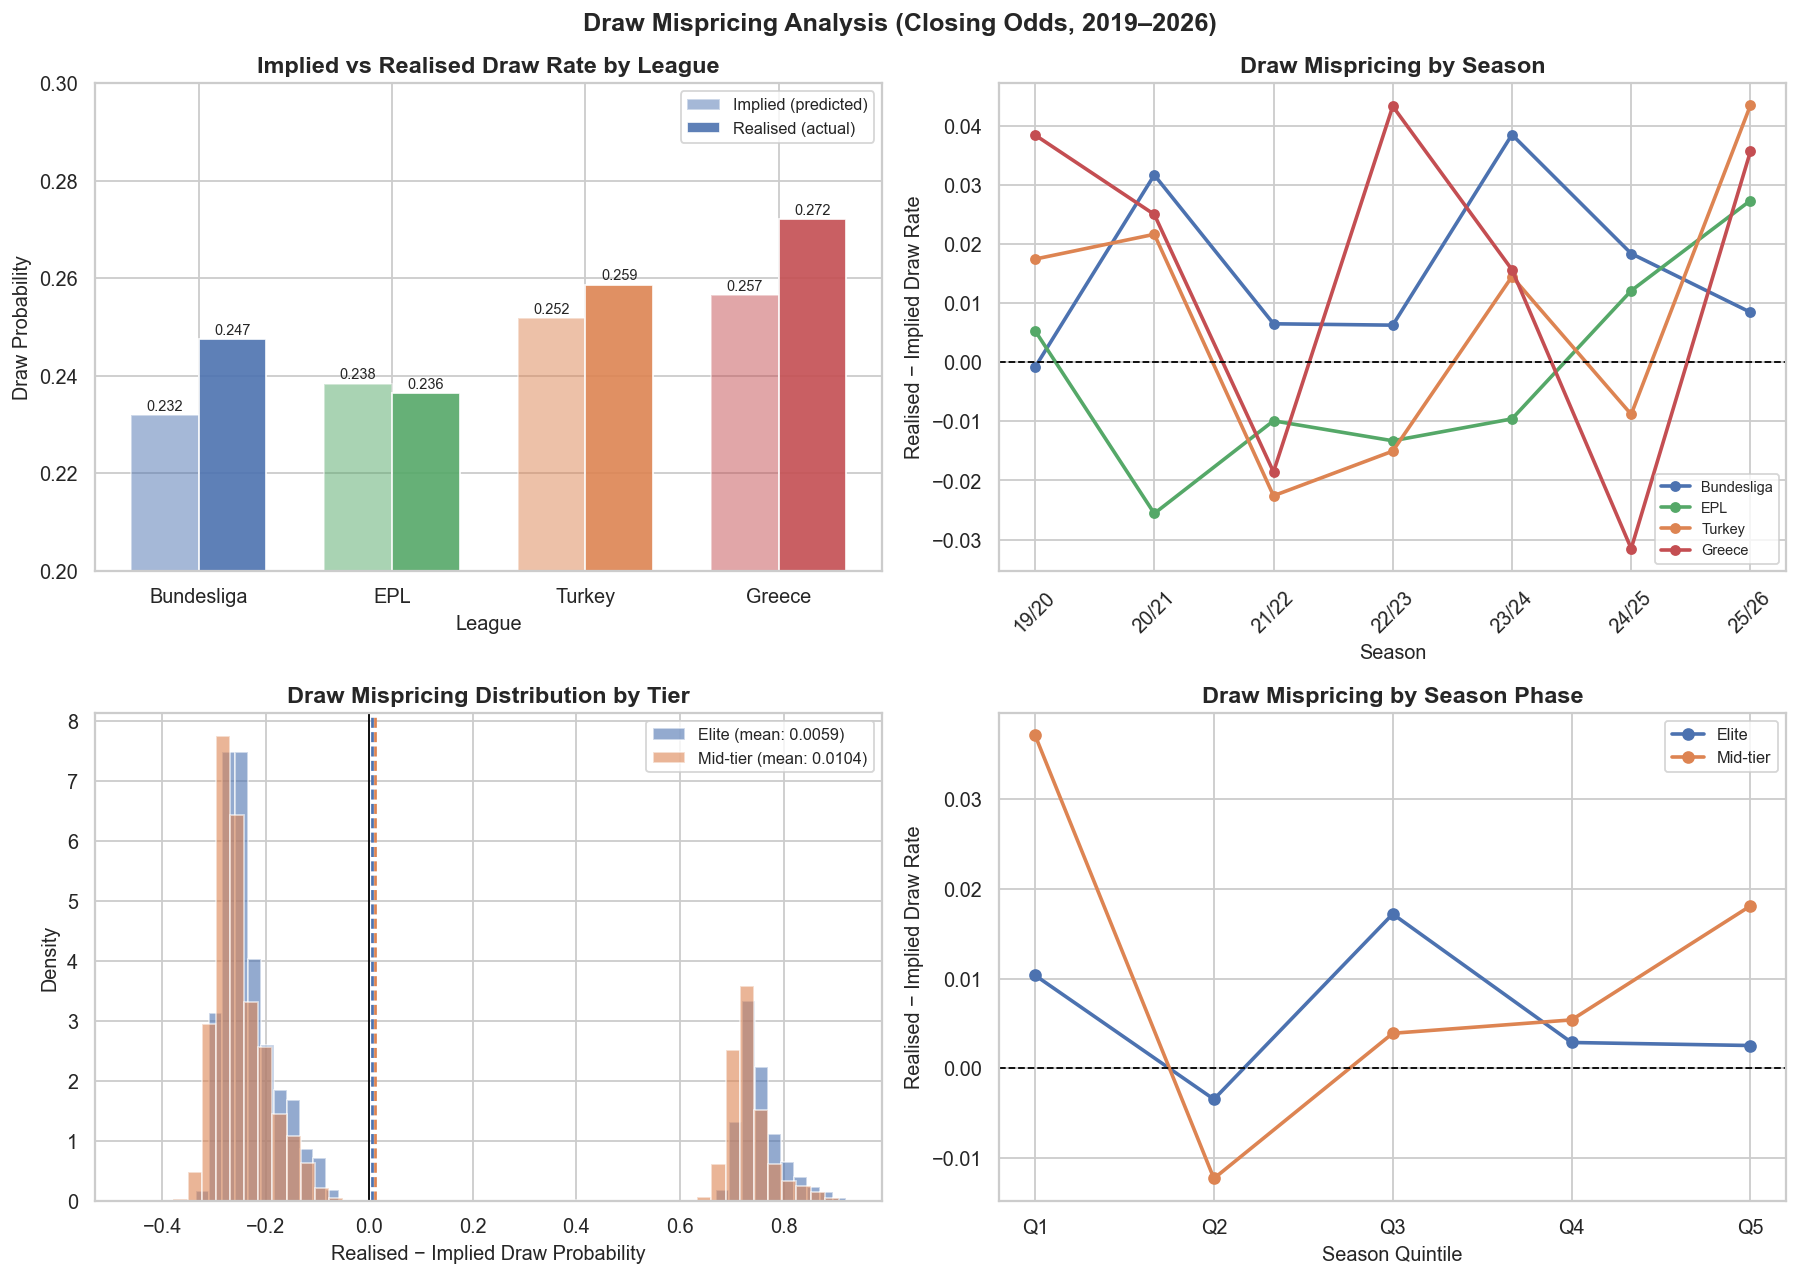

=== Draw Mispricing Summary ===

League          Implied   Realised       Bias     Bias %
----------------------------------------------------
Bundesliga       0.2318     0.2474    +0.0156      +6.7%
EPL              0.2384     0.2365    -0.0019      -0.8%
Turkey           0.2517     0.2587    +0.0069      +2.8%
Greece           0.2565     0.2721    +0.0156      +6.1%

=== Draw Mispricing by Season (mean bias) ===

Season    Bundesliga         EPL      Turkey      Greece
--------------------------------------------------------
19/20        -0.0008     +0.0054     +0.0175     +0.0385
20/21        +0.0317     -0.0256     +0.0217     +0.0250
21/22        +0.0065     -0.0099     -0.0226     -0.0185
22/23        +0.0063     -0.0133     -0.0150     +0.0433
23/24        +0.0385     -0.0096     +0.0145     +0.0157
24/25        +0.0184     +0.0121     -0.0088     -0.0315
25/26        +0.0085     +0.0274     +0.0435     +0.0357


In [57]:
# Build draw-specific frame using closing odds
draw_df = master.dropna(subset=['B365CH', 'B365CD', 'B365CA']).copy()

# Normalised implied draw probability (closing)
draw_df['raw_draw_prob'] = 1 / draw_df['B365CD']
draw_df['implied_sum'] = (1/draw_df['B365CH'] + 1/draw_df['B365CD'] + 1/draw_df['B365CA'])
draw_df['draw_prob_norm'] = draw_df['raw_draw_prob'] / draw_df['implied_sum']
draw_df['draw_occurred'] = (draw_df['FTR'] == 'D').astype(int)
draw_df['draw_mispricing'] = draw_df['draw_occurred'] - draw_df['draw_prob_norm']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 — implied vs realised draw rate by league
league_stats = []
for league, name in zip(['D1','E0','T1','G1'],
                         ['Bundesliga','EPL','Turkey','Greece']):
    sub = draw_df[draw_df['league'] == league]
    league_stats.append({
        'league': name,
        'implied': sub['draw_prob_norm'].mean(),
        'realised': sub['draw_occurred'].mean(),
        'bias': sub['draw_mispricing'].mean(),
        'n': len(sub)
    })

stats_df = pd.DataFrame(league_stats)
x = range(len(stats_df))
width = 0.35
colors_league = ['#4C72B0','#55A868','#DD8452','#C44E52']

bars1 = axes[0,0].bar([i - width/2 for i in x], stats_df['implied'],
                       width, label='Implied (predicted)', color=colors_league, alpha=0.5)
bars2 = axes[0,0].bar([i + width/2 for i in x], stats_df['realised'],
                       width, label='Realised (actual)', color=colors_league, alpha=0.9)

axes[0,0].set_title('Implied vs Realised Draw Rate by League', fontweight='bold')
axes[0,0].set_xlabel('League')
axes[0,0].set_ylabel('Draw Probability')
axes[0,0].set_xticks(list(x))
axes[0,0].set_xticklabels(stats_df['league'])
axes[0,0].legend(fontsize=9)
axes[0,0].set_ylim(0.20, 0.30)
for i, row in stats_df.iterrows():
    axes[0,0].text(i - width/2, row['implied'] + 0.001,
                   f"{row['implied']:.3f}", ha='center', fontsize=8)
    axes[0,0].text(i + width/2, row['realised'] + 0.001,
                   f"{row['realised']:.3f}", ha='center', fontsize=8)

# Chart 2 — draw mispricing by season and league
season_labels = ['19/20','20/21','21/22','22/23','23/24','24/25','25/26']
for league, name, color in zip(['D1','E0','T1','G1'],
                                ['Bundesliga','EPL','Turkey','Greece'],
                                ['#4C72B0','#55A868','#DD8452','#C44E52']):
    season_bias = (draw_df[draw_df['league'] == league]
                   .groupby('season')['draw_mispricing']
                   .mean()
                   .reindex(['1920','2021','2122','2223','2324','2425','2526']))
    axes[0,1].plot(season_labels, season_bias.values, marker='o',
                   color=color, label=name, linewidth=2, markersize=5)

axes[0,1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0,1].set_title('Draw Mispricing by Season', fontweight='bold')
axes[0,1].set_xlabel('Season')
axes[0,1].set_ylabel('Realised − Implied Draw Rate')
axes[0,1].legend(fontsize=8)
axes[0,1].tick_params(axis='x', rotation=45)

# Chart 3 — draw mispricing distribution by tier
for tier, color, label in zip(['elite','mid_tier'],
                               ['#4C72B0','#DD8452'],
                               ['Elite','Mid-tier']):
    data = draw_df[draw_df['tier'] == tier]['draw_mispricing']
    axes[1,0].hist(data, bins=50, alpha=0.6, density=True,
                   color=color, label=f'{label} (mean: {data.mean():.4f})')
    axes[1,0].axvline(data.mean(), color=color, linestyle='--', linewidth=1.5)

axes[1,0].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1,0].set_title('Draw Mispricing Distribution by Tier', fontweight='bold')
axes[1,0].set_xlabel('Realised − Implied Draw Probability')
axes[1,0].set_ylabel('Density')
axes[1,0].legend(fontsize=9)

# Chart 4 — draw rate by season quintile and tier
draw_df['match_rank'] = draw_df.groupby(['league','season'])['Date'].rank(method='first')
draw_df['season_size'] = draw_df.groupby(['league','season'])['Date'].transform('count')
draw_df['season_pct'] = draw_df['match_rank'] / draw_df['season_size']
draw_df['season_quintile'] = pd.cut(
    draw_df['season_pct'],
    bins=[0,0.2,0.4,0.6,0.8,1.0],
    labels=['Q1','Q2','Q3','Q4','Q5']
)

for tier, color, label in zip(['elite','mid_tier'],
                               ['#4C72B0','#DD8452'],
                               ['Elite','Mid-tier']):
    sub = draw_df[draw_df['tier'] == tier]
    q_bias = sub.groupby('season_quintile', observed=True)['draw_mispricing'].mean()
    axes[1,1].plot(q_bias.index, q_bias.values, marker='o',
                   color=color, label=label, linewidth=2, markersize=6)

axes[1,1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1,1].set_title('Draw Mispricing by Season Phase', fontweight='bold')
axes[1,1].set_xlabel('Season Quintile')
axes[1,1].set_ylabel('Realised − Implied Draw Rate')
axes[1,1].legend(fontsize=9)

fig.suptitle('Draw Mispricing Analysis (Closing Odds, 2019–2026)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_12_draw_mispricing.png', bbox_inches='tight')
plt.show()

# Summary
print("=== Draw Mispricing Summary ===\n")
print(f"{'League':<12} {'Implied':>10} {'Realised':>10} {'Bias':>10} {'Bias %':>10}")
print("-" * 52)
for _, row in stats_df.iterrows():
    bias_pct = (row['bias'] / row['implied']) * 100
    print(f"{row['league']:<12} {row['implied']:>10.4f} {row['realised']:>10.4f} "
          f"{row['bias']:>+10.4f} {bias_pct:>+9.1f}%")

print(f"\n=== Draw Mispricing by Season (mean bias) ===\n")
print(f"{'Season':<8}", end='')
for name in ['Bundesliga','EPL','Turkey','Greece']:
    print(f"{name:>12}", end='')
print()
print("-" * 56)
for season, label in zip(['1920','2021','2122','2223','2324','2425','2526'], season_labels):
    print(f"{label:<8}", end='')
    for league in ['D1','E0','T1','G1']:
        val = draw_df[(draw_df['league']==league) & 
                      (draw_df['season']==season)]['draw_mispricing'].mean()
        print(f"{val:>+12.4f}", end='')
    print()

**Observation (Draw Mispricing):** EPL is the only correctly priced draw market 
(bias −0.8%). All other leagues systematically underprice draws: Bundesliga (+6.7%), 
Greece (+6.1%), Turkey (+2.8%). Greece draws happen 27.2% of the time vs 25.7% 
predicted — a persistent structural gap across 7 seasons. The most extreme seasonal 
spikes are Greece 22/23 (+4.3pp) and Turkey 25/26 (+4.4pp) — both warrant targeted 
investigation in the anomaly detection phase. Mid-tier draw mispricing is concentrated 
in Q1 (early season, +3.8pp) and dissipates toward season end, suggesting bookmaker 
uncertainty about team quality drives early-season draw underpricing rather than 
end-of-season manipulation incentives. The Bundesliga's persistent draw underpricing 
in recent seasons (23/24 to 25/26) is a structural market characteristic rather than 
an integrity signal.

## 7. EDA Complete Summary

Full findings from exploratory data analysis across all six analytical sections.

### 7.1 Master findings table

In [58]:
summary = {
    'Finding': [
        'Mid-tier away spread 43% wider than elite',
        'Mid-tier bookmaker margin 29% higher than elite',
        'Greece least efficient — away spread 64% wider than EPL',
        'Elite markets improving over 7 seasons — mid-tier flat',
        'Result distributions consistent across all leagues',
        'H4 not supported — Greece spread peaks mid-season (Q3)',
        'EPL most accurate bookmaker (54.5% favourite win rate)',
        'Greece home favourite accuracy near random (50.5%)',
        'Market well-calibrated overall — mid-tier bias at extremes',
        'Mid-tier FLB: favourites win more, longshots win less',
        'EPL only correctly priced draw market (−0.8% bias)',
        'Greece draws 27.2% vs 25.7% predicted (+6.1% bias)',
        'Greece Pinnacle away drift 71% wider than EPL',
        'Turkey highest away spread widening rate (69.8%)',
        'Draw spread widens in Greece (54.5%), narrows in Turkey (46.8%)',
        'Greece 22/23 and Turkey 25/26 extreme draw spikes (+4.3-4.4pp)',
    ],
    'Hypothesis': [
        'H1','H1','H1','H1','—','H4','H1','H1',
        'H1','H1','H2','H2','H1','H1','H2','H2'
    ],
    'Direction': [
        '✅ Supported','✅ Supported','✅ Supported','✅ Supported',
        'ℹ️ Baseline','❌ Rejected as framed','✅ Supported','✅ Supported',
        '✅ Supported','✅ Supported','✅ Supported','⚠️ Flag',
        '✅ Supported','⚠️ Flag','⚠️ Flag','⚠️ Investigate'
    ]
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

                                                        Finding Hypothesis            Direction
                      Mid-tier away spread 43% wider than elite         H1          ✅ Supported
                Mid-tier bookmaker margin 29% higher than elite         H1          ✅ Supported
        Greece least efficient — away spread 64% wider than EPL         H1          ✅ Supported
         Elite markets improving over 7 seasons — mid-tier flat         H1          ✅ Supported
             Result distributions consistent across all leagues          —          ℹ️ Baseline
         H4 not supported — Greece spread peaks mid-season (Q3)         H4 ❌ Rejected as framed
         EPL most accurate bookmaker (54.5% favourite win rate)         H1          ✅ Supported
             Greece home favourite accuracy near random (50.5%)         H1          ✅ Supported
     Market well-calibrated overall — mid-tier bias at extremes         H1          ✅ Supported
          Mid-tier FLB: favourites win m

### 7.2 Save final master_enriched with all EDA columns

In [64]:
# Recompute season position features on final master
# (ensures consistency after all cleaning and feature computation steps)
master['match_rank'] = master.groupby(['league','season'])['Date'].rank(method='first')
master['season_size'] = master.groupby(['league','season'])['Date'].transform('count')
master['season_pct'] = master['match_rank'] / master['season_size']
master['season_quintile'] = pd.cut(
    master['season_pct'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
)

# Final save
master.to_csv('../data/processed/master_enriched.csv', index=False)

print("Saved: data/processed/master_enriched.csv")
print(f"Final shape: {master.shape}")
print(f"\nColumn count by group:")
print(f"  Match info + result:          6")
print(f"  Raw odds (open+close, 4x):   24")
print(f"  Metadata:                     3")
print(f"  Drift (B365 + Pinnacle):      6")
print(f"  Spread (open + close):        8")
print(f"  Spread change:                4")
print(f"  B365 vs market gap:           3")
print(f"  Implied prob sum:             2")
print(f"  Season position:              4")
print(f"  EDA aliases (bookmaker_spread, max_spread, implied_prob_sum): 5")
print(f"  Total: {len(master.columns)}")

Saved: data/processed/master_enriched.csv
Final shape: (8914, 66)

Column count by group:
  Match info + result:          6
  Raw odds (open+close, 4x):   24
  Metadata:                     3
  Drift (B365 + Pinnacle):      6
  Spread (open + close):        8
  Spread change:                4
  B365 vs market gap:           3
  Implied prob sum:             2
  Season position:              4
  EDA aliases (bookmaker_spread, max_spread, implied_prob_sum): 5
  Total: 66
